# 21. 도로 영역을 찾자! — U-Net vs U-Net++ 세그멘테이션 [프로젝트]

**과제**: KITTI 데이터셋으로 도로 영역 시맨틱 세그멘테이션을 수행하고, **U-Net**과 직접 구현한 **U-Net++** 의 성능을 정량적(IoU)·정성적(시각화)으로 비교한다.

| 루브릭 | 대응 섹션 |
| --- | --- |
| 1. U-Net 세그멘테이션 한 사이클 정상 수행 | Step 1 · Step 2 · Step 4-A · Step 6 |
| 2. U-Net++ 모델 자체 구현 및 학습 | Step 3 · Step 4-B |
| 3. 두 모델 정량/정성 비교 | Step 5 · Step 6 |

### PRT(Peer Review Template) 대응

| PRT 항목 | 이 노트북에서의 위치 |
| --- | --- |
| 1. 완성된 코드와 최종 결과물 | Step 4~6 실행 결과, `output/comparison_best_mid_worst.png`, `output/overlay_*.png` |
| 2. 핵심 코드의 주석/docstring | `UNetPlusPlus` (수식 ↔ 코드 대응, 채널 계산), `train_model`, `BCEDiceLoss` |
| 3. 디버깅 기록 · 추가 실험 | Step 8 디버깅 기록(①~⑥), Step 7 threshold 스윕 / DS ablation / 가지별 평가(7-3) / 페어드 부트스트랩(7-4) / seed 반복(7-5) |
| 4. 회고 | Step 9, 상단 실행 플로우 그래프 |
| 5. 간결성·효율성 | 공통 블록(`DoubleConv`/`UpBlock`) 분리, 두 모델이 `train_model`·`evaluate` 공유, `Config` 단일화 |

---

## 📊 전체 코드 실행 플로우

```
                        ┌──────────────────────────┐
                        │  Step 0. 설정 · 재현성    │
                        │  CFG / seed 고정          │
                        └────────────┬─────────────┘
                                     ▼
                        ┌──────────────────────────┐
                        │  Step 1. 데이터셋 구축     │
                        │  build_augmentation()     │
                        │  KittiDataset             │
                        │  → train / val DataLoader │
                        │  ✔ 데이터 검증(sanity)    │
                        └────────────┬─────────────┘
                                     ▼
              ┌──────────────────────┴──────────────────────┐
              │        Step 2~3. 모델 정의 (공통 블록)        │
              │        DoubleConv · UpBlock                  │
              └──────────┬───────────────────────┬───────────┘
                         ▼                       ▼
              ┌────────────────────┐  ┌────────────────────────┐
              │  UNet              │  │  UNetPlusPlus          │
              │  (baseline)        │  │  (nested skip + DS)    │
              └──────────┬─────────┘  └───────────┬────────────┘
                         │                        │
                         └───────────┬────────────┘
                                     ▼
                        ┌──────────────────────────┐
                        │  공통 학습 파이프라인      │
                        │  BCEDiceLoss             │
                        │  train_model()  ← 재사용  │
                        │  evaluate()     ← 재사용  │
                        └────────────┬─────────────┘
                                     ▼
                ┌────────────────────┴────────────────────┐
                ▼                                         ▼
   ┌────────────────────────┐              ┌────────────────────────┐
   │ Step 4-A. U-Net 학습    │              │ Step 4-B. U-Net++ 학습  │
   │ → history_unet          │              │ → history_unetpp        │
   │ → best_unet.pth         │              │ → best_unetpp.pth       │
   └───────────┬────────────┘              └───────────┬────────────┘
               └──────────────────┬──────────────────--┘
                                  ▼
                     ┌──────────────────────────┐
                     │  Step 5. 정량 비교         │
                     │  mean IoU · Dice · 파라미터│
                     │  학습 곡선 plot            │
                     └────────────┬─────────────┘
                                  ▼
                     ┌──────────────────────────┐
                     │  Step 6. 정성 비교         │
                     │  원본/정답/U-Net/U-Net++   │
                     │  overlay 결과 이미지 저장  │
                     └────────────┬─────────────┘
                                  ▼
                     ┌──────────────────────────┐
                     │  Step 7. 추가 실험         │
                     │  threshold sweep          │
                     │  deep supervision 유무     │
                     └────────────┬─────────────┘
                                  ▼
                     ┌──────────────────────────┐
                     │  Step 8. 디버깅 기록·회고  │
                     └──────────────────────────┘
```


---

## Step 0-A. Colab (L4 GPU) 환경 준비

> 이 노트북은 **Colab L4 GPU(VRAM 약 22GB)** 기준으로 설정되어 있다.
> `런타임 → 런타임 유형 변경 → L4 GPU` 를 먼저 확인할 것.

세션이 끊기면 학습 결과가 날아가므로, 체크포인트는 **Google Drive에 저장**하는 것을 권장한다.


In [ ]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
print("Colab 환경:", IN_COLAB)

if IN_COLAB:
    # 그래프의 한글이 깨지지 않도록 나눔폰트를 설치한다.
    # albumentations는 버전에 따라 API가 달라지지만, 아래 build_augmentation()이
    # 설치된 버전을 자동으로 감지해 맞춰 쓰므로 따로 업그레이드하지 않는다.
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)
    subprocess.run(["fc-cache", "-f"], check=False, capture_output=True)
    print("폰트 설치 완료.")

Colab 환경: True
폰트 설치 완료.


In [ ]:
!nvidia-smi

Wed Sep  2 12:39:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
MOUNT_DRIVE = False   # True로 바꾸면 체크포인트를 Google Drive에 저장한다.

DRIVE_OUT = None
if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    # 실제 폴더 생성은 CFG가 정의된 뒤에 한다.
    DRIVE_OUT = "/content/drive/MyDrive/aiffel/semantic_segmentation/output"
    print("Drive 저장 경로:", DRIVE_OUT)
else:
    print("Drive를 마운트하지 않습니다. 세션 종료 시 체크포인트가 사라집니다.")

Drive를 마운트하지 않습니다. 세션 종료 시 체크포인트가 사라집니다.


---

## Step 0. 환경 설정과 재현성

실험 조건을 한곳(`CFG`)에 모아 두면 **U-Net과 U-Net++를 완전히 동일한 조건에서 비교**할 수 있다.
비교 실험에서 통제하지 않은 변수가 하나라도 있으면 성능 차이의 원인을 모델 구조로 돌릴 수 없다.


In [ ]:
import os
import random
import time
import json
from glob import glob
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from PIL import Image
from skimage.io import imread

import albumentations as A

print("torch        :", torch.__version__)
print("numpy        :", np.__version__)
print("PIL          :", Image.__version__ if hasattr(Image, "__version__") else "n/a")
print("albumentations:", A.__version__)

torch        : 2.11.0+cu128
numpy        : 2.1.3
PIL          : 11.3.0
albumentations: 2.0.8


In [ ]:
@dataclass
class Config:
    """실험 전체를 지배하는 하이퍼파라미터.

    두 모델을 공정하게 비교하기 위해 `batch_size`, `epochs`, `lr`, `base_channels`,
    `seed`를 모두 공유한다. U-Net++는 U-Net보다 메모리를 많이 쓰므로 batch_size는
    U-Net++ 기준(작은 값)으로 맞춰 두 모델 모두에 동일하게 적용한다.

    Note:
        Colab L4(VRAM 약 22GB) 기준 기본값이다. OOM이 나면 batch_size를 먼저 절반으로
        줄이고, 그래도 부족하면 base_channels를 32로 낮춘다. 어느 쪽을 바꾸든
        **두 모델 모두에 똑같이 적용해야** 비교가 유효하다.

        `ds_weights`/`val_branch`는 deep supervision(DS) 전용 옵션이다. 첫 실행에서
        DS 모델이 오히려 진 원인이 **학습·평가 불일치**로 의심됐기 때문에 추가했다
        (Step 8 디버깅 기록 ⑥). 기본값은 첫 실행과 동일하므로, 그대로 두면 이전
        결과가 그대로 재현된다.
    """

    data_dir: str = "/content/kitti/data_semantics/training"
    out_dir: str = "/content/kitti/output"

    img_size: int = 224
    road_label: int = 7        # Cityscapes 라벨 규격에서 road == 7
    val_size: int = 30         # 뒤에서 N장을 검증셋으로 분리

    base_channels: int = 64    # L4(22GB)에서는 논문 기본값 64를 그대로 쓸 수 있다
    up_mode: str = "transpose"  # "transpose" | "upsample"
    dropout: float = 0.5

    batch_size: int = 8        # U-Net++ 메모리 기준으로 두 모델 모두 통일
    epochs: int = 60
    lr: float = 1e-4
    bce_weight: float = 0.5    # loss = w*BCE + (1-w)*Dice
    threshold: float = 0.5

    # --- deep supervision 전용 ---
    ds_weights: str = "uniform"  # "uniform"(논문 기본) | "deep"(깊은 가지에 가중치)
    val_branch: str = "last"     # 검증·체크포인트 선택 기준 가지: "last" | "mean" | "0"~"3"

    use_amp: bool = True       # L4는 fp16 연산이 빠르다. CPU에서는 자동으로 꺼진다
    seed: int = 42
    num_workers: int = 2       # Colab CPU 코어 수에 맞춘 값
    pin_memory: bool = True


CFG = Config()
if DRIVE_OUT:                     # Drive를 마운트했다면 결과를 그쪽에 저장
    CFG.out_dir = DRIVE_OUT
os.makedirs(CFG.out_dir, exist_ok=True)
print(json.dumps(asdict(CFG), indent=2, ensure_ascii=False))

{
  "data_dir": "/content/kitti/data_semantics/training",
  "out_dir": "/content/kitti/output",
  "img_size": 224,
  "road_label": 7,
  "val_size": 30,
  "base_channels": 64,
  "up_mode": "transpose",
  "dropout": 0.5,
  "batch_size": 8,
  "epochs": 60,
  "lr": 0.0001,
  "bce_weight": 0.5,
  "threshold": 0.5,
  "ds_weights": "uniform",
  "val_branch": "last",
  "use_amp": true,
  "seed": 42,
  "num_workers": 2,
  "pin_memory": true
}


In [ ]:
def set_seed(seed: int = 42) -> None:
    """난수 시드를 고정해 실행할 때마다 같은 결과가 나오도록 한다.

    Args:
        seed: 고정할 시드 값.

    Note:
        cudnn.benchmark를 끄면 속도가 다소 느려지지만, 두 모델을 비교하는
        실험에서는 "실행할 때마다 값이 달라지는 것"이 훨씬 큰 비용이다.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


In [ ]:
def setup_korean_font():
    """matplotlib 그래프에 한글이 깨지지 않도록 폰트를 설정한다.

    설치된 한글 폰트를 순서대로 찾아 적용하고, 하나도 없으면 경고만 남기고
    기본 폰트를 유지한다(그림 자체는 정상 출력된다).
    """
    import matplotlib
    from matplotlib import font_manager

    candidates = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic",
                  "AppleGothic", "Noto Sans CJK KR"]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            matplotlib.rcParams["font.family"] = name
            matplotlib.rcParams["axes.unicode_minus"] = False
            print("한글 폰트 적용:", name)
            return name
    print("한글 폰트를 찾지 못했습니다. 그래프 제목의 한글이 깨질 수 있습니다.")
    print("설치: !apt-get install -y fonts-nanum  후 커널 재시작")
    return None


setup_korean_font()

한글 폰트를 찾지 못했습니다. 그래프 제목의 한글이 깨질 수 있습니다.
설치: !apt-get install -y fonts-nanum  후 커널 재시작


---

## Step 1. KITTI 데이터셋 수집과 구축

### 1-1. 데이터 다운로드

이미 받아 두었다면 건너뛴다.

```
data/training/
├── image_2/    원본 RGB 이미지
└── semantic/   클래스 ID 라벨 이미지 (road == 7)
```


In [ ]:
# 이미 데이터가 있으면 다시 받지 않는다 (약 300MB).
KITTI_ROOT = "/content/kitti"
ZIP_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip"

if not os.path.isdir(os.path.join(CFG.data_dir, "image_2")):
    !mkdir -p /content/kitti
    !wget -q --show-progress -O /content/kitti/data_semantics.zip $ZIP_URL
    !unzip -q /content/kitti/data_semantics.zip -d /content/kitti/data_semantics
else:
    print("데이터가 이미 존재합니다:", CFG.data_dir)


def locate_training_dir(root):
    """압축 해제 결과에서 image_2/semantic 을 모두 가진 폴더를 찾는다.

    zip 구조가 버전에 따라 다를 수 있어 경로를 하드코딩하지 않고 탐색한다.

    Returns:
        찾은 디렉토리 경로. 없으면 None.
    """
    if not root or not os.path.isdir(root):
        return None
    for cur, dirs, _ in os.walk(root):
        if "image_2" in dirs and "semantic" in dirs:
            return cur
    return None


if not os.path.isdir(os.path.join(CFG.data_dir, "image_2")):
    # CFG.data_dir에서 위로 올라가며 실제로 존재하는 조상 폴더를 찾고,
    # 거기서부터 탐색한다. 그래도 못 찾으면 KITTI_ROOT에서 한 번 더 본다.
    search_root = CFG.data_dir
    while search_root and not os.path.isdir(search_root):
        parent = os.path.dirname(search_root)
        if parent == search_root:
            break
        search_root = parent

    found = locate_training_dir(search_root) or locate_training_dir(KITTI_ROOT)
    if found is None:
        raise FileNotFoundError(
            "image_2/semantic 폴더를 찾지 못했습니다. "
            "다운로드와 압축 해제가 끝났는지 확인하세요."
        )
    print("경로 자동 보정:", CFG.data_dir, "->", found)
    CFG.data_dir = found

n_img = len(glob(os.path.join(CFG.data_dir, "image_2", "*.png")))
n_lab = len(glob(os.path.join(CFG.data_dir, "semantic", "*.png")))
print("data_dir:", CFG.data_dir)
print(f"이미지 {n_img}장 / 라벨 {n_lab}장")
assert n_img > 0 and n_img == n_lab, "이미지와 라벨 수가 맞지 않습니다."

/content/kitti/data 100%[===================>] 312.52M  14.7MB/s    in 24s     
data_dir: /content/kitti/data_semantics/training
이미지 200장 / 라벨 200장


### 1-2. Augmentation 정의

`image`와 `mask`를 **같은 파이프라인에 함께** 통과시켜야 좌우반전·크롭이 이미지와 라벨에 동일하게 적용된다.
albumentations는 `mask=` 로 전달된 배열에 **nearest 보간**을 적용하므로 클래스 ID가 뭉개지지 않는다.


In [ ]:
import inspect


def _random_sized_crop(min_max_height, size, w2h_ratio, p):
    """설치된 albumentations 버전에 맞는 RandomSizedCrop을 생성한다.

    albumentations 1.4 부터 crop 크기 지정 방식이 `height`/`width`에서
    `size` 튜플로 바뀌었다. 구버전에 `size`를 넘기면 인자가 조용히 무시되어
    의도와 다른 크기가 나오고, 신버전에 `height`를 넘기면 경고 후 무시된다.
    둘 다 학습이 되긴 하므로 눈치채기 어려운 종류의 버그다.

    그래서 버전 번호를 비교하는 대신 **생성자의 시그니처를 직접 확인**해
    맞는 인자로 호출한다. 이렇게 하면 어떤 환경에서도 pip 업그레이드나
    런타임 재시작 없이 그대로 동작한다.

    Args:
        min_max_height: 잘라낼 영역 높이의 (최소, 최대).
        size: 최종 crop 크기 (height, width).
        w2h_ratio: 잘라낼 영역의 가로/세로 비.
        p: 적용 확률.

    Returns:
        A.RandomSizedCrop 인스턴스.
    """
    params = inspect.signature(A.RandomSizedCrop.__init__).parameters
    if "size" in params:                      # albumentations >= 1.4
        return A.RandomSizedCrop(min_max_height=min_max_height, size=size,
                                 w2h_ratio=w2h_ratio, p=p)
    return A.RandomSizedCrop(min_max_height=min_max_height,               # < 1.4
                             height=size[0], width=size[1],
                             w2h_ratio=w2h_ratio, p=p)


def build_augmentation(img_size: int = 224, is_train: bool = True) -> A.Compose:
    """학습/검증용 augmentation 파이프라인을 만든다.

    Args:
        img_size: 최종 출력 한 변의 길이(정사각형).
        is_train: True면 무작위 증강 포함, False면 Resize만 수행.

    Returns:
        image와 mask를 함께 처리하는 albumentations Compose 객체.

    Note:
        image와 mask를 같은 Compose에 함께 넘겨야 좌우반전·크롭이 둘에
        동일하게 적용된다. 또한 albumentations는 `mask=`로 받은 배열에
        nearest 보간을 적용하므로 클래스 ID가 뭉개지지 않는다.
    """
    if is_train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            _random_sized_crop(
                min_max_height=(300, 370),
                size=(img_size, img_size),
                w2h_ratio=370 / 1242,   # KITTI 원본 종횡비 유지
                p=0.5,
            ),
            A.Resize(height=img_size, width=img_size),
        ])
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
    ])


print("albumentations", A.__version__,
      "| RandomSizedCrop 인자:",
      "size" if "size" in inspect.signature(A.RandomSizedCrop.__init__).parameters
      else "height/width")

albumentations 2.0.8 | RandomSizedCrop 인자: size


### 1-3. `KittiDataset`

라벨 이미지를 `road == 7` 기준의 **이진 마스크**로 바꿔 픽셀별 이진 분류 문제로 단순화한다.


In [ ]:
class KittiDataset(Dataset):
    """KITTI semantic segmentation 데이터셋(도로 이진 마스크 버전).

    원본 라벨은 클래스 ID 이미지(0~33)지만, 이 프로젝트는 "도로 / 도로 아님"의
    이진 분할만 다루므로 `label == road_label` 을 1, 나머지를 0으로 변환한다.

    Attributes:
        data: (원본 이미지 경로, 라벨 이미지 경로) 튜플의 리스트.

    Note:
        KITTI 테스트셋은 정답 라벨을 제공하지 않는다. 따라서 여기서 만드는
        검증셋은 training 폴더의 뒤쪽 `val_size` 장을 떼어낸 것이다.
        파일명을 정렬한 뒤 뒤에서 자르므로, 두 모델이 항상 같은 검증셋을 본다.
    """

    def __init__(self, dir_path, img_size=224, road_label=7,
                 val_size=30, is_train=True, augmentation=None):
        self.dir_path = dir_path
        self.img_size = img_size
        self.road_label = road_label
        self.val_size = val_size
        self.is_train = is_train
        self.augmentation = augmentation
        self.data = self._load_dataset()

    def _load_dataset(self):
        """이미지/라벨 경로 쌍을 만들고 train·val로 분할한다."""
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) > 0, f"이미지를 찾지 못했습니다: {self.dir_path}"
        assert len(input_images) == len(label_images), (
            f"이미지 {len(input_images)}장 != 라벨 {len(label_images)}장"
        )

        pairs = list(zip(input_images, label_images))
        return pairs[:-self.val_size] if self.is_train else pairs[-self.val_size:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        """전처리된 (이미지, 마스크) 텐서 쌍을 반환한다.

        Returns:
            image: float32 텐서, shape (3, H, W), 값 범위 [0, 1]
            mask : float32 텐서, shape (1, H, W), 값 {0.0, 1.0}
        """
        image_path, label_path = self.data[index]

        image = imread(image_path)
        label = imread(label_path)

        # 클래스 ID 이미지 → 도로 이진 마스크. 이진화를 augmentation보다
        # 먼저 하는 이유: 보간이 개입하기 전에 값을 확정해 두기 위함.
        mask = (label == self.road_label).astype(np.uint8)

        if self.augmentation is not None:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        image = torch.from_numpy(image.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)
        return image, mask

In [ ]:
train_dataset = KittiDataset(
    CFG.data_dir, img_size=CFG.img_size, road_label=CFG.road_label,
    val_size=CFG.val_size, is_train=True,
    augmentation=build_augmentation(CFG.img_size, is_train=True),
)
val_dataset = KittiDataset(
    CFG.data_dir, img_size=CFG.img_size, road_label=CFG.road_label,
    val_size=CFG.val_size, is_train=False,
    augmentation=build_augmentation(CFG.img_size, is_train=False),
)

loader_kwargs = dict(num_workers=CFG.num_workers,
                     pin_memory=CFG.pin_memory and torch.cuda.is_available(),
                     persistent_workers=CFG.num_workers > 0)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True,
                          drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False,
                        **loader_kwargs)

print(f"train: {len(train_dataset)}장  |  val: {len(val_dataset)}장")

train: 170장  |  val: 30장


### 1-4. 데이터 검증 (sanity check)

> **데이터셋에 오류가 없어야 성능이 안 나올 때 원인을 찾을 수 있다.**
> 학습을 돌리기 전에 아래 세 가지를 반드시 확인한다.
> 1. shape / dtype / 값 범위가 의도대로인가
> 2. 마스크에 **0과 1 이외의 값**이 섞이지 않았는가 (= 보간 오염 여부)
> 3. augmentation이 이미지와 마스크에 **똑같이** 적용되는가


In [ ]:
def check_dataset(dataset, n_samples=8):
    """데이터셋이 의도대로 파싱되는지 검사하고 통계를 출력한다.

    Raises:
        AssertionError: 마스크에 0/1 이외의 값이 섞여 있는 경우.
            이는 라벨에 bilinear 보간이 적용됐다는 신호이므로 반드시 잡아야 한다.
    """
    image, mask = dataset[0]
    print(f"image shape={tuple(image.shape)} dtype={image.dtype} "
          f"range=[{image.min():.3f}, {image.max():.3f}]")
    print(f"mask  shape={tuple(mask.shape)} dtype={mask.dtype} "
          f"unique={torch.unique(mask).tolist()}")

    ratios = []
    for i in range(min(n_samples, len(dataset))):
        _, m = dataset[i]
        uniq = torch.unique(m).tolist()
        assert set(uniq).issubset({0.0, 1.0}), (
            f"[{i}] 마스크에 0/1 이외의 값 {uniq} 존재 → 라벨에 보간이 적용됨"
        )
        ratios.append(m.mean().item())

    print(f"도로 픽셀 비율: 평균 {np.mean(ratios):.3f} "
          f"(min {np.min(ratios):.3f} / max {np.max(ratios):.3f})")
    print("→ 배경이 압도적으로 많은 불균형 데이터. Dice Loss를 함께 쓰는 근거.")


check_dataset(train_dataset)
check_dataset(val_dataset)

image shape=(3, 224, 224) dtype=torch.float32 range=[0.008, 1.000]
mask  shape=(1, 224, 224) dtype=torch.float32 unique=[0.0, 1.0]
도로 픽셀 비율: 평균 0.150 (min 0.000 / max 0.253)
→ 배경이 압도적으로 많은 불균형 데이터. Dice Loss를 함께 쓰는 근거.
image shape=(3, 224, 224) dtype=torch.float32 range=[0.004, 1.000]
mask  shape=(1, 224, 224) dtype=torch.float32 unique=[0.0, 1.0]
도로 픽셀 비율: 평균 0.236 (min 0.163 / max 0.386)
→ 배경이 압도적으로 많은 불균형 데이터. Dice Loss를 함께 쓰는 근거.


/tmp/ipykernel_5743/3600726298.py:19: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/3600726298.py:19: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


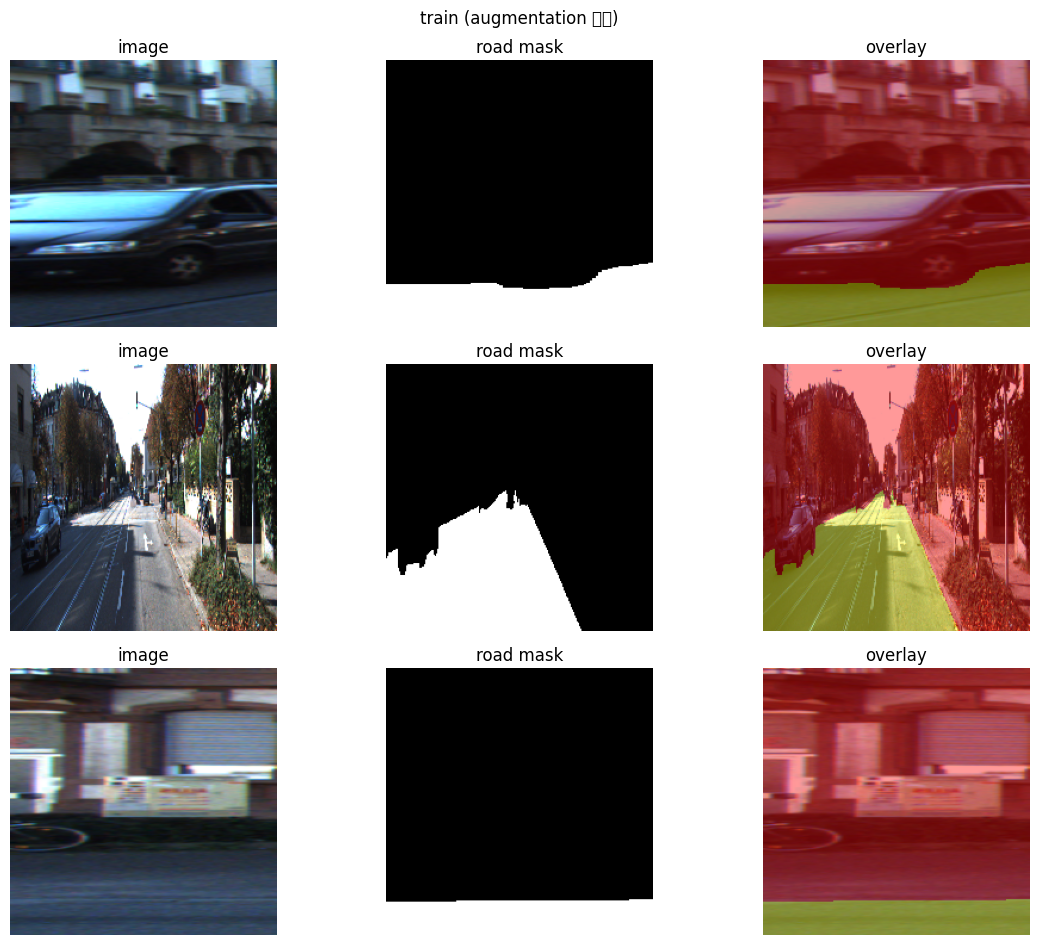

/tmp/ipykernel_5743/3600726298.py:19: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


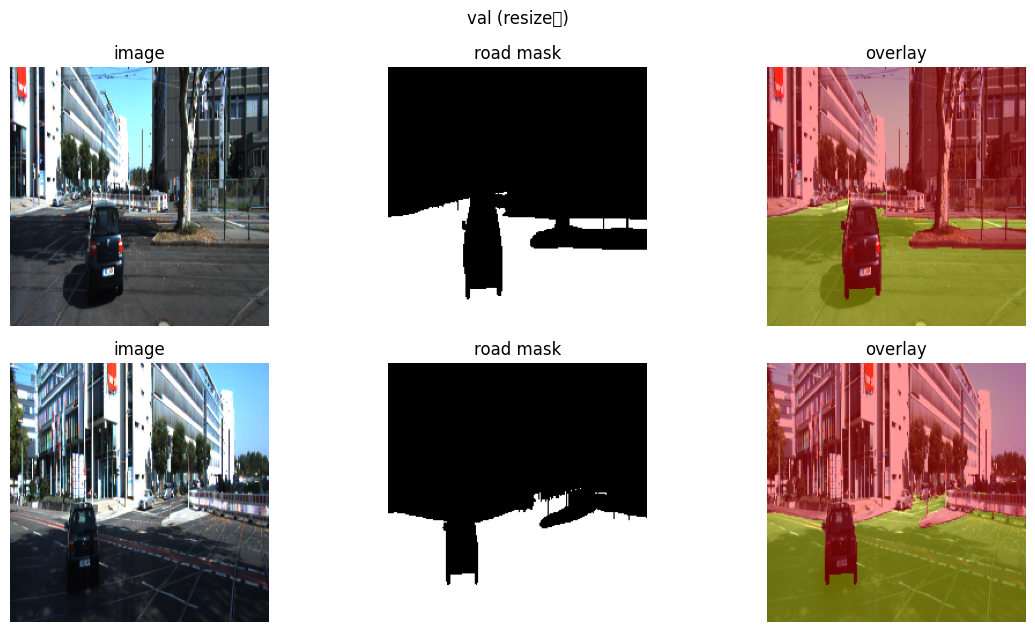

In [ ]:
def show_samples(dataset, n=3, title=""):
    """이미지와 마스크가 짝이 맞게 증강되는지 눈으로 확인한다."""
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * n))
    for i in range(n):
        image, mask = dataset[i]
        img_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze(0).numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("image")
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("road mask")
        axes[i, 2].imshow(img_np)
        axes[i, 2].imshow(mask_np, cmap="autumn", alpha=0.4)
        axes[i, 2].set_title("overlay")
        for ax in axes[i]:
            ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_samples(train_dataset, n=3, title="train (augmentation 적용)")
show_samples(val_dataset, n=2, title="val (resize만)")

---

## Step 2. 공통 빌딩 블록과 U-Net (baseline)

U-Net과 U-Net++는 **같은 부품**으로 만들어진다. 부품을 먼저 분리해 두면
두 모델의 차이가 "부품"이 아니라 **"연결 방식"** 뿐이라는 점이 코드에서 드러나고,
`up_mode` 같은 옵션을 두 모델에 동시에 바꿔 끼울 수 있다.

```
DoubleConv : Conv3x3 → BN → ReLU → Conv3x3 → BN → ReLU   (= 논문의 H)
UpBlock    : ConvTranspose2d 또는 Upsample+Conv1x1        (= 논문의 u)
torch.cat  : 채널 방향 연결                                (= 논문의 [ ])
```


In [ ]:
class DoubleConv(nn.Module):
    """3x3 Conv → BN → ReLU 를 두 번 반복하는 기본 블록 (논문의 H(·)).

    원 논문 U-Net에는 BatchNorm이 없지만, 배치가 작고 학습 데이터가 170장뿐인
    이 환경에서는 BN을 넣는 쪽이 수렴이 훨씬 안정적이었다. `use_batchnorm`으로
    끄고 켤 수 있게 해 두어 두 모델에 동일 조건으로 적용한다.

    Args:
        in_channels: 입력 채널 수.
        out_channels: 출력 채널 수.
        use_batchnorm: BatchNorm 사용 여부. True면 Conv의 bias는 불필요하므로 끈다.
    """

    def __init__(self, in_channels, out_channels, use_batchnorm=True):
        super().__init__()
        layers = []
        for cin, cout in ((in_channels, out_channels), (out_channels, out_channels)):
            layers.append(nn.Conv2d(cin, cout, kernel_size=3, padding=1,
                                    bias=not use_batchnorm))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(cout))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """특성 맵을 2배로 키우는 업샘플링 블록 (논문의 u(·)).

    U-Net++ 참고 구현이 제공하는 두 방식을 모두 지원한다.
        - "transpose": ConvTranspose2d. 업샘플링 방식 자체를 학습한다.
        - "upsample" : Bilinear Upsample + 1x1 Conv. 파라미터가 적고 체커보드
                       아티팩트가 없지만 표현력은 조금 낮다.

    Raises:
        ValueError: 지원하지 않는 mode가 들어온 경우.
    """

    def __init__(self, in_channels, out_channels, mode="transpose"):
        super().__init__()
        if mode == "transpose":
            self.up = nn.ConvTranspose2d(in_channels, out_channels,
                                         kernel_size=2, stride=2)
        elif mode == "upsample":
            self.up = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            )
        else:
            raise ValueError(f"지원하지 않는 up_mode: {mode}")

    def forward(self, x):
        return self.up(x)

In [ ]:
class UNet(nn.Module):
    """비교 기준(baseline)이 되는 U-Net.

    원 논문과 달리 모든 Conv에 padding=1을 주어 입력과 출력의 해상도가 같다
    (224x224 → 224x224). 따라서 예측 결과를 원본 크기로 되돌리는 후처리가
    필요 없다.

    Args:
        input_channels: 입력 채널 수 (RGB면 3).
        output_channels: 출력 채널 수. 도로 이진 분할이므로 1.
        base_channels: 최상단 채널 수. 아래로 갈수록 2배씩 늘어난다.
        up_mode: UpBlock의 업샘플링 방식.
        dropout: bottleneck에 적용할 Dropout2d 비율.

    Note:
        forward는 **로짓(logit)** 을 반환한다. sigmoid를 모델 안에서 적용하지
        않는 이유는 BCEWithLogitsLoss가 log-sum-exp 트릭으로 수치적으로 더
        안정적이기 때문이다. 확률이 필요한 시점(추론·시각화)에만 sigmoid를 건다.
    """

    def __init__(self, input_channels=3, output_channels=1, base_channels=32,
                 up_mode="transpose", dropout=0.5, use_batchnorm=True):
        super().__init__()
        f = [base_channels * (2 ** i) for i in range(5)]  # [32, 64, 128, 256, 512]

        # Contracting path
        self.enc0 = DoubleConv(input_channels, f[0], use_batchnorm)
        self.enc1 = DoubleConv(f[0], f[1], use_batchnorm)
        self.enc2 = DoubleConv(f[1], f[2], use_batchnorm)
        self.enc3 = DoubleConv(f[2], f[3], use_batchnorm)
        self.bottleneck = DoubleConv(f[3], f[4], use_batchnorm)

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout2d(dropout)

        # Expansive path. skip과 cat하므로 DoubleConv의 입력은 f[i] * 2 이다.
        self.up3 = UpBlock(f[4], f[3], up_mode)
        self.dec3 = DoubleConv(f[3] * 2, f[3], use_batchnorm)
        self.up2 = UpBlock(f[3], f[2], up_mode)
        self.dec2 = DoubleConv(f[2] * 2, f[2], use_batchnorm)
        self.up1 = UpBlock(f[2], f[1], up_mode)
        self.dec1 = DoubleConv(f[1] * 2, f[1], use_batchnorm)
        self.up0 = UpBlock(f[1], f[0], up_mode)
        self.dec0 = DoubleConv(f[0] * 2, f[0], use_batchnorm)

        self.final = nn.Conv2d(f[0], output_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.enc0(x)                    # (B, f0, 224, 224)
        x1 = self.enc1(self.pool(x0))        # (B, f1, 112, 112)
        x2 = self.enc2(self.pool(x1))        # (B, f2,  56,  56)
        x3 = self.enc3(self.pool(x2))        # (B, f3,  28,  28)
        x4 = self.dropout(self.bottleneck(self.pool(x3)))   # (B, f4, 14, 14)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        d0 = self.dec0(torch.cat([self.up0(d1), x0], dim=1))
        return self.final(d0)                # (B, 1, 224, 224) 로짓

---

## Step 3. U-Net++ 구현

### 논문의 수식을 코드로 옮기기

$$X^{i,j} = H\bigl([\,X^{i,0},\,X^{i,1},\,\dots,\,X^{i,j-1},\;u(X^{i+1,\,j-1})\,]\bigr)$$

| 기호 | 의미 | 코드 |
| --- | --- | --- |
| $H$ | conv 블록 | `DoubleConv` |
| $u$ | 업샘플링 | `UpBlock` |
| $[\;]$ | 채널 방향 연결 | `torch.cat(..., dim=1)` |

**노드 $X^{i,j}$ 의 입력 채널 수**는 "같은 행의 이전 노드 $j$개" + "아래 행에서 올라온 것 1개" = **$f_i \times (j+1)$** 이다.
이 한 줄이 U-Net++ 구현의 핵심이자, 가장 실수하기 쉬운 지점이다.

```
X0,0 ─→ X0,1 ─→ X0,2 ─→ X0,3 ─→ X0,4 → 출력(+ deep supervision)
 │↓      ↑↗      ↑↗      ↑↗      ↑↗
X1,0 ─→ X1,1 ─→ X1,2 ─→ X1,3
 │↓      ↑↗      ↑↗
X2,0 ─→ X2,1 ─→ X2,2
 │↓      ↑↗
X3,0 ─→ X3,1
 │↓      ↑
X4,0

 ─→ = 같은 행의 skip(concat)   ↓ = down-sampling   ↑↗ = up-sampling 후 concat
 j=0 열만 남기고 나머지를 지우면 정확히 U-Net이 된다.
```

**Deep supervision**: $X^{0,1} \sim X^{0,4}$ 각각에 1x1 conv를 달아 4개의 출력을 만들고
손실을 평균낸다. 얕은 가지에도 직접 gradient가 전달되어 학습이 안정되고,
추론 시 뒷가지를 잘라내는 **pruning** 도 가능해진다.


In [ ]:
class UNetPlusPlus(nn.Module):
    """U-Net++ (Nested U-Net). U-Net의 긴 skip을 촘촘한 중첩 skip으로 대체한다.

    U-Net의 skip connection은 인코더의 특성을 그대로 디코더에 붙인다. 이때 두
    특성 맵의 의미 수준(semantic level) 차이가 커서 학습이 어렵다는 것이
    U-Net++ 논문의 문제 제기다. U-Net++는 그 사이를 중간 conv 노드로 촘촘히
    메워 의미 차이를 줄인다.

    Args:
        input_channels: 입력 채널 수.
        output_channels: 출력 채널 수.
        base_channels: 최상단 채널 수.
        up_mode: "transpose" 또는 "upsample".
        deep_supervision: True면 X^{0,1}~X^{0,4} 4개의 로짓을 리스트로 반환한다.
        dropout: 가장 깊은 노드 X^{4,0}에 적용할 Dropout2d 비율.

    Note:
        노드를 `nn.ModuleDict`에 "i_j" 키로 담는다. 이렇게 하면 깊이(5단계)를
        바꿔도 forward 로직을 고칠 필요가 없고, 논문 수식과 코드가 1:1로 대응해
        읽기 쉽다. 파이썬 dict에 그냥 담으면 파라미터가 등록되지 않아 학습이
        전혀 되지 않으므로 반드시 ModuleDict를 써야 한다.
    """

    DEPTH = 5

    def __init__(self, input_channels=3, output_channels=1, base_channels=32,
                 up_mode="transpose", deep_supervision=False, dropout=0.5,
                 use_batchnorm=True):
        super().__init__()
        f = [base_channels * (2 ** i) for i in range(self.DEPTH)]
        self.deep_supervision = deep_supervision
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout2d(dropout)

        self.conv = nn.ModuleDict()
        self.up = nn.ModuleDict()

        # ---- j = 0 : 기존 U-Net과 동일한 인코더 백본 ----
        self.conv["0_0"] = DoubleConv(input_channels, f[0], use_batchnorm)
        for i in range(1, self.DEPTH):
            self.conv[f"{i}_0"] = DoubleConv(f[i - 1], f[i], use_batchnorm)

        # ---- j >= 1 : 중첩 디코더 노드 ----
        # X^{i,j}의 입력 = 같은 행의 이전 노드 j개 + 아래 행에서 올라온 1개
        #              = f[i] * (j + 1) 채널
        for j in range(1, self.DEPTH):
            for i in range(self.DEPTH - j):
                self.up[f"{i}_{j}"] = UpBlock(f[i + 1], f[i], up_mode)
                self.conv[f"{i}_{j}"] = DoubleConv(f[i] * (j + 1), f[i], use_batchnorm)

        if deep_supervision:
            self.final = nn.ModuleList([
                nn.Conv2d(f[0], output_channels, kernel_size=1)
                for _ in range(self.DEPTH - 1)
            ])
        else:
            self.final = nn.Conv2d(f[0], output_channels, kernel_size=1)

    def forward(self, x):
        """
        Returns:
            deep_supervision=False → 로짓 텐서 (B, 1, H, W)
            deep_supervision=True  → 로짓 텐서 4개의 리스트
        """
        node = {}

        # 인코더 (아래로 내려가며 해상도 1/2, 채널 2배)
        node["0_0"] = self.conv["0_0"](x)
        for i in range(1, self.DEPTH):
            node[f"{i}_0"] = self.conv[f"{i}_0"](self.pool(node[f"{i-1}_0"]))
        node["4_0"] = self.dropout(node["4_0"])

        # 중첩 디코더 (열 단위로 왼쪽 위를 향해 채워 나간다)
        for j in range(1, self.DEPTH):
            for i in range(self.DEPTH - j):
                dense = [node[f"{i}_{k}"] for k in range(j)]      # 같은 행의 이전 노드들
                dense.append(self.up[f"{i}_{j}"](node[f"{i+1}_{j-1}"]))  # 아래 행에서 up
                node[f"{i}_{j}"] = self.conv[f"{i}_{j}"](torch.cat(dense, dim=1))

        if self.deep_supervision:
            return [self.final[j - 1](node[f"0_{j}"]) for j in range(1, self.DEPTH)]
        return self.final(node["0_4"])

### 3-1. 구현 검증 — shape과 파라미터 수

학습을 돌리기 전에 **더미 텐서로 forward를 통과시켜** 출력 shape이 라벨과 맞는지 확인한다.
여기서 걸리는 버그(특히 `cat` 채널 수 불일치)를 학습 루프에서 만나면 원인 파악이 훨씬 어렵다.


In [ ]:
def count_params(model: nn.Module) -> int:
    """학습 가능한 파라미터 개수를 센다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def check_model_io(model, name, img_size=224, batch=2):
    """더미 입력으로 forward를 통과시켜 출력 shape을 검증한다."""
    model.eval()
    with torch.no_grad():
        out = model(torch.randn(batch, 3, img_size, img_size))
    if isinstance(out, list):
        shapes = [tuple(o.shape) for o in out]
        for s in shapes:
            assert s == (batch, 1, img_size, img_size), f"{name} shape 불일치: {s}"
    else:
        shapes = tuple(out.shape)
        assert shapes == (batch, 1, img_size, img_size), f"{name} shape 불일치: {shapes}"
    print(f"{name:24s} params={count_params(model):>11,}  out={shapes}")


check_model_io(UNet(base_channels=CFG.base_channels, up_mode=CFG.up_mode), "UNet")
check_model_io(UNetPlusPlus(base_channels=CFG.base_channels, up_mode=CFG.up_mode),
               "UNet++")
check_model_io(UNetPlusPlus(base_channels=CFG.base_channels, up_mode=CFG.up_mode,
                            deep_supervision=True), "UNet++ (deep supervision)")

UNet                     params= 31,037,633  out=(2, 1, 224, 224)
UNet++                   params= 36,165,249  out=(2, 1, 224, 224)
UNet++ (deep supervision) params= 36,165,444  out=[(2, 1, 224, 224), (2, 1, 224, 224), (2, 1, 224, 224), (2, 1, 224, 224)]


---

## Step 4. 손실 함수 · 평가 지표 · 학습 루프 (두 모델 공용)

### 4-1. BCE + Dice Loss

논문이 사용하는 조합이다. 도로 픽셀은 전체의 일부에 불과한 **불균형 데이터**라
BCE만 쓰면 "전부 배경"으로 찍는 해에 빠지기 쉽다. Dice는 IoU처럼 **겹치는 영역의 비율**을
직접 최적화하므로 이 편향을 상쇄한다.

```
Dice coefficient = (2 · |A ∩ B| + s) / (|A| + |B| + s)
Dice Loss        = 1 − Dice coefficient
Total Loss       = w · BCE + (1 − w) · DiceLoss        (w = CFG.bce_weight)
```


In [ ]:
class DiceLoss(nn.Module):
    """Soft Dice Loss. 로짓을 입력으로 받는다.

    Args:
        smooth: 분모가 0이 되는 것을 막는 평활항. 예측과 정답이 모두 비어 있는
            배치에서 loss가 발산하지 않도록 한다.

    Note:
        임계값으로 이진화하지 않고 sigmoid 확률을 그대로 쓴다(soft dice).
        이진화는 미분이 불가능해 역전파가 되지 않기 때문이다.
    """

    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # autocast(fp16) 아래에서 sigmoid/합산을 하면 언더플로가 생길 수 있어
        # float32로 올린 뒤 계산한다. BCEWithLogitsLoss는 autocast-safe라 그대로 둔다.
        probs = torch.sigmoid(logits.float())
        targets = targets.float()
        p = probs.reshape(probs.size(0), -1)
        t = targets.reshape(targets.size(0), -1)
        intersection = (p * t).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (p.sum(dim=1) + t.sum(dim=1) + self.smooth)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """BCEWithLogits + Dice 결합 손실. deep supervision 출력(list)도 처리한다.

    Args:
        bce_weight: BCE에 줄 가중치 w. Dice에는 (1 - w)가 적용된다.
        smooth: DiceLoss의 평활항.
        ds_weights: deep supervision 가지에 줄 가중치 배분 방식.
            - "uniform": 네 가지를 균등 평균 (논문 기본값, 첫 실행과 동일)
            - "deep"   : 깊은 가지일수록 큰 가중치 (1,2,3,4를 합 1로 정규화)
            - 리스트   : 직접 지정 (내부에서 합 1로 정규화)

    Note:
        모델이 로짓을 반환하므로 BCELoss가 아니라 BCEWithLogitsLoss를 쓴다.
        모델 안에서 sigmoid를 적용한 뒤 BCEWithLogitsLoss를 쓰면 sigmoid가
        두 번 걸려 학습이 망가지므로, 둘 중 하나만 있어야 한다.

        **ds_weights를 둔 이유**: "uniform"이면 평가에 쓰이는 X^{0,4}가 받는 직접
        감독 신호가 non-DS 대비 1/4로 줄어든다. 얕은 가지 X^{0,1}은 인코더에서 한
        칸 올라온 것뿐인데 손실의 1/4을 차지하므로, 같은 lr·같은 epoch에서 최종
        가지가 덜 학습된 상태로 끝난다. "deep"은 그 불일치를 줄여 보는 옵션이다.
    """

    def __init__(self, bce_weight: float = 0.5, smooth: float = 1.0,
                 ds_weights="uniform"):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth)
        self.bce_weight = bce_weight
        self.ds_weights = ds_weights

    def _single(self, logits, targets):
        w = self.bce_weight
        return w * self.bce(logits, targets) + (1.0 - w) * self.dice(logits, targets)

    def _branch_weights(self, n: int):
        """가지 수 n에 대한 가중치 리스트를 합 1로 정규화해 반환한다."""
        if isinstance(self.ds_weights, str):
            if self.ds_weights == "deep":
                raw = [float(k + 1) for k in range(n)]   # 뒤로 갈수록 크게
            else:                                        # "uniform"
                raw = [1.0] * n
        else:
            raw = [float(v) for v in self.ds_weights]
            assert len(raw) == n, f"ds_weights 길이 {len(raw)} != 가지 수 {n}"
        total = sum(raw)
        return [v / total for v in raw]

    def final_only(self, logits, targets):
        """마지막 가지(X^{0,4}) 하나만으로 계산한 손실.

        DS 모델의 학습 손실은 얕은 가지까지 평균낸 값이라 non-DS 모델의 손실과
        **같은 축의 숫자가 아니다**. 모델 간 loss를 나란히 놓고 비교하려면
        이 값을 써야 한다.
        """
        if isinstance(logits, (list, tuple)):
            logits = logits[-1]
        return self._single(logits, targets)

    def forward(self, logits, targets):
        if isinstance(logits, (list, tuple)):   # deep supervision
            weights = self._branch_weights(len(logits))
            return sum(w * self._single(b, targets) for w, b in zip(weights, logits))
        return self._single(logits, targets)


# --- sanity check: uniform이면 기존 동작(단순 평균)과 완전히 같아야 한다 ---
_lg = [torch.randn(2, 1, 16, 16) for _ in range(4)]
_tg = (torch.rand(2, 1, 16, 16) > 0.7).float()
_crit = BCEDiceLoss(0.5, ds_weights="uniform")
_mean = sum(_crit._single(b, _tg) for b in _lg) / 4
print("uniform == 단순평균 :", torch.allclose(_crit(_lg, _tg), _mean))
print("deep 가중치         :", [round(w, 3) for w in _crit._branch_weights(4)],
      "->", [round(w, 3) for w in BCEDiceLoss(ds_weights="deep")._branch_weights(4)])

uniform == 단순평균 : True
deep 가중치         : [0.25, 0.25, 0.25, 0.25] -> [0.1, 0.2, 0.3, 0.4]


### 4-2. 평가 지표 — IoU와 Dice

`intersection / union` 을 **배치 단위가 아니라 이미지 단위로** 계산한 뒤 평균낸다.
배치 전체를 한 덩어리로 합쳐 계산하면 도로가 넓게 찍힌 이미지가 점수를 지배해,
도로가 거의 없는 이미지에서의 실패가 가려진다.


In [ ]:
def to_probs(logits, branch="last"):
    """모델 출력에서 평가에 쓸 **확률 맵**을 뽑는다.

    Args:
        logits: 단일 로짓 텐서 또는 deep supervision 로짓 리스트.
        branch: 리스트일 때 어느 가지를 쓸지.
            - "last" : 가장 깊은 가지 X^{0,4} (기본값, 첫 실행과 동일)
            - "mean" : 네 가지의 **확률을 평균**낸 앙상블
            - 0~3 또는 "0"~"3": 해당 인덱스의 가지 (0 = X^{0,1})

    Returns:
        (B, 1, H, W) 확률 텐서.

    Note:
        앙상블은 로짓이 아니라 sigmoid를 통과시킨 뒤 평균낸다. 로짓 평균은
        가지마다 스케일이 달라 큰 값 하나가 결과를 지배할 수 있다.
    """
    if not isinstance(logits, (list, tuple)):
        return torch.sigmoid(logits.float())
    if branch == "mean":
        return torch.stack([torch.sigmoid(b.float()) for b in logits]).mean(dim=0)
    idx = -1 if branch == "last" else int(branch)
    return torch.sigmoid(logits[idx].float())


@torch.no_grad()
def compute_iou(logits, targets, threshold=0.5, eps=1e-7, branch="last"):
    """이미지별 IoU를 계산해 평균을 반환한다.

    Args:
        logits: 모델 출력 로짓. deep supervision이면 `branch`로 가지를 고른다.
        targets: 정답 마스크 (B, 1, H, W), 값 {0, 1}.
        threshold: 확률을 이진화할 임계값.
        branch: to_probs() 참고. 기본값 "last"는 첫 실행과 동일한 동작이다.

    Returns:
        배치 내 이미지별 IoU의 평균 (float).
    """
    pred = (to_probs(logits, branch) > threshold).float()
    targets = targets.float()
    intersection = (pred * targets).sum(dim=(1, 2, 3))
    union = ((pred + targets) > 0).float().sum(dim=(1, 2, 3))
    return ((intersection + eps) / (union + eps)).mean().item()


@torch.no_grad()
def compute_dice(logits, targets, threshold=0.5, eps=1e-7, branch="last"):
    """이미지별 Dice 계수를 계산해 평균을 반환한다."""
    pred = (to_probs(logits, branch) > threshold).float()
    targets = targets.float()
    intersection = (pred * targets).sum(dim=(1, 2, 3))
    total = pred.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * intersection + eps) / (total + eps)).mean().item()


# --- 지표 sanity check: 완벽한 예측은 1.0, 반대로 찍으면 0.0 이어야 한다 ---
_t = (torch.rand(2, 1, 32, 32) > 0.7).float()
_perfect = torch.where(_t > 0.5, torch.tensor(10.0), torch.tensor(-10.0))
print("perfect  → IoU", round(compute_iou(_perfect, _t), 4),
      "| Dice", round(compute_dice(_perfect, _t), 4))
print("inverted → IoU", round(compute_iou(-_perfect, _t), 4),
      "| Dice", round(compute_dice(-_perfect, _t), 4))

# --- 가지 선택 sanity check: 리스트를 넣어도 지정한 가지만 평가돼야 한다 ---
_ds = [-_perfect, -_perfect, -_perfect, _perfect]      # 마지막 가지만 정답
print("DS list, branch='last' → IoU", round(compute_iou(_ds, _t, branch="last"), 4),
      "| branch=0 → IoU", round(compute_iou(_ds, _t, branch=0), 4),
      "| branch='mean' → IoU", round(compute_iou(_ds, _t, branch="mean"), 4))

perfect  → IoU 1.0 | Dice 1.0
inverted → IoU 0.0 | Dice 0.0
DS list, branch='last' → IoU 1.0 | branch=0 → IoU 0.0 | branch='mean' → IoU 0.0


### 4-3. 학습 · 평가 루프

**두 모델에 똑같이 쓰는 하나의 함수**로 만든다. 모델별로 학습 코드를 복사해 두면
비교 실험 도중 한쪽만 고치는 실수가 반드시 생긴다.


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5, branch="last"):
    """검증셋 전체에 대한 평균 loss / IoU / Dice를 계산한다.

    Args:
        branch: deep supervision 모델에서 평가에 쓸 가지. to_probs() 참고.

    Returns:
        dict: {"loss", "loss_final", "iou", "dice"}
            - loss       : 학습에 실제로 쓰는 손실. DS면 가지 평균값이라
                           **non-DS 모델과 직접 비교하면 안 된다.**
            - loss_final : 마지막 가지 하나로만 계산한 손실. 모델 간 비교용.
    """
    model.eval()
    totals = {"loss": 0.0, "loss_final": 0.0, "iou": 0.0, "dice": 0.0}
    n_batches = 0

    amp_on = bool(getattr(loader, "_amp", False)) or device.type == "cuda"
    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=amp_on):
            logits = model(images)
        loss_all = criterion(logits, masks).item()
        # final_only는 이 노트북의 BCEDiceLoss에만 있다. 다른 손실을 넘겨도
        # 죽지 않도록 없으면 학습 손실을 그대로 쓴다.
        final_fn = getattr(criterion, "final_only", None)
        totals["loss"] += loss_all
        totals["loss_final"] += (final_fn(logits, masks).item()
                                 if final_fn is not None else loss_all)
        totals["iou"] += compute_iou(logits, masks, threshold, branch=branch)
        totals["dice"] += compute_dice(logits, masks, threshold, branch=branch)
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in totals.items()}


def train_model(model, train_loader, val_loader, cfg, device,
                ckpt_name="model.pth", verbose_every=5, val_branch=None):
    """모델을 학습하고 검증 IoU가 가장 높은 시점의 가중치를 저장한다.

    Args:
        model: 학습할 nn.Module (로짓을 반환해야 한다).
        train_loader / val_loader: DataLoader.
        cfg: Config 인스턴스.
        device: torch.device.
        ckpt_name: 저장할 체크포인트 파일명.
        verbose_every: 몇 epoch마다 로그를 찍을지.
        val_branch: DS 모델의 검증 기준 가지. None이면 cfg.val_branch를 쓴다.

    Returns:
        (model, history) — model은 best 가중치가 로드된 상태,
        history는 epoch별 지표가 담긴 dict.

    Note:
        마지막 epoch가 아니라 **검증 IoU 최고 시점**을 저장한다. 데이터가 170장뿐이라
        후반부에 과적합으로 성능이 떨어지는 경우가 흔하고, 그 상태를 제출하면
        모델 구조가 아니라 학습 종료 시점 때문에 비교가 왜곡되기 때문이다.

        다만 `best_iou`는 **같은 검증셋 30장에 대한 60번의 측정 중 최댓값**이므로
        낙관적으로 치우친 수치다. 그래서 history에 마지막 epoch 값(`final_iou`)과
        마지막 5 epoch의 평균±표준편차(`last5_iou_mean`, `last5_iou_std`)를 함께
        기록한다. 모델 간 차이가 이 표준편차보다 작으면 "차이가 없다"고 읽어야 한다.
    """
    model = model.to(device)
    criterion = BCEDiceLoss(bce_weight=cfg.bce_weight,
                            ds_weights=getattr(cfg, "ds_weights", "uniform"))
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=8)

    branch = val_branch if val_branch is not None else getattr(cfg, "val_branch", "last")

    # AMP는 CUDA에서만 의미가 있다. CPU면 자동으로 비활성화된다.
    amp_on = bool(cfg.use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_on)
    if amp_on:
        torch.cuda.reset_peak_memory_stats(device)

    ckpt_path = os.path.join(cfg.out_dir, ckpt_name)
    history = {"train_loss": [], "val_loss": [], "val_loss_final": [],
               "val_iou": [], "val_dice": []}
    best_iou, best_epoch = -1.0, -1
    start = time.time()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running = 0.0
        for images, masks in train_loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=amp_on):
                loss = criterion(model(images), masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item()

        train_loss = running / max(len(train_loader), 1)
        val = evaluate(model, val_loader, criterion, device, cfg.threshold, branch=branch)
        scheduler.step(val["iou"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val["loss"])
        history["val_loss_final"].append(val["loss_final"])
        history["val_iou"].append(val["iou"])
        history["val_dice"].append(val["dice"])

        if val["iou"] > best_iou:
            best_iou, best_epoch = val["iou"], epoch
            torch.save(model.state_dict(), ckpt_path)

        if epoch % verbose_every == 0 or epoch == 1 or epoch == cfg.epochs:
            print(f"[{epoch:3d}/{cfg.epochs}] "
                  f"train_loss={train_loss:.4f}  val_loss={val['loss']:.4f}  "
                  f"val_IoU={val['iou']:.4f}  val_Dice={val['dice']:.4f}")

    elapsed = time.time() - start
    peak_gb = (torch.cuda.max_memory_allocated(device) / 1024 ** 3
               if amp_on else float("nan"))

    last5 = history["val_iou"][-5:]
    history["best_iou"] = best_iou
    history["best_epoch"] = best_epoch
    history["final_iou"] = history["val_iou"][-1]
    history["last5_iou_mean"] = float(np.mean(last5))
    history["last5_iou_std"] = float(np.std(last5))
    history["elapsed_sec"] = elapsed
    history["peak_vram_gb"] = peak_gb
    history["val_branch"] = branch
    history["ds_weights"] = getattr(cfg, "ds_weights", "uniform")

    print(f"\n완료: best val IoU={best_iou:.4f} (epoch {best_epoch}) | "
          f"마지막 5 epoch 평균 {history['last5_iou_mean']:.4f}"
          f"±{history['last5_iou_std']:.4f} | "
          f"소요 {elapsed/60:.1f}분 | peak VRAM {peak_gb:.1f}GB | 저장 → {ckpt_path}")
    print(f"  ※ best_iou는 {cfg.epochs}회 측정의 최댓값이라 낙관적이다. "
          f"모델 간 비교는 위의 ± 폭과 함께 읽을 것.")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history

### 4-4. VRAM · 속도 프로브 (L4에서 배치 크기 결정하기)

`CFG.batch_size`로 실제 1 step을 돌려 **peak VRAM과 step 시간**을 측정한다.
학습을 60 epoch 돌린 뒤 OOM으로 죽는 것보다, 여기서 30초 안에 확인하는 편이 낫다.
OOM이 나면 batch_size를 절반으로 줄이고 **두 모델 모두에** 동일하게 적용한다.


In [ ]:
def probe_step(model_fn, cfg, device, label):
    """1 step의 forward+backward를 돌려 peak VRAM과 소요 시간을 측정한다.

    Returns:
        dict 또는 None (OOM 발생 시 None과 함께 안내 메시지 출력).
    """
    if device.type != "cuda":
        print(f"{label}: CUDA가 아니므로 프로브를 건너뜁니다.")
        return None

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)

    model = model_fn().to(device)
    criterion = BCEDiceLoss(bce_weight=cfg.bce_weight)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp)

    images = torch.randn(cfg.batch_size, 3, cfg.img_size, cfg.img_size, device=device)
    masks = (torch.rand(cfg.batch_size, 1, cfg.img_size, cfg.img_size,
                        device=device) > 0.7).float()

    try:
        for _ in range(3):                      # 워밍업 포함 3 step
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=cfg.use_amp):
                loss = criterion(model(images), masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        torch.cuda.synchronize()

        start = time.time()
        for _ in range(5):
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=cfg.use_amp):
                loss = criterion(model(images), masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        torch.cuda.synchronize()
        step_sec = (time.time() - start) / 5
        peak_gb = torch.cuda.max_memory_allocated(device) / 1024 ** 3

        steps_per_epoch = max(len(train_loader), 1)
        print(f"{label:26s} peak VRAM {peak_gb:5.2f}GB | "
              f"{step_sec*1000:6.0f}ms/step | "
              f"예상 {step_sec*steps_per_epoch:5.1f}s/epoch | "
              f"{cfg.epochs}epoch ≈ {step_sec*steps_per_epoch*cfg.epochs/60:.0f}분")
        return {"peak_gb": peak_gb, "step_sec": step_sec}

    except torch.cuda.OutOfMemoryError:
        print(f"{label}: OOM! batch_size({cfg.batch_size}) 또는 "
              f"base_channels({cfg.base_channels})를 줄이세요.")
        return None
    finally:
        del model, optimizer
        torch.cuda.empty_cache()


probe_step(lambda: UNet(base_channels=CFG.base_channels, up_mode=CFG.up_mode),
           CFG, DEVICE, "UNet")
probe_step(lambda: UNetPlusPlus(base_channels=CFG.base_channels, up_mode=CFG.up_mode,
                                deep_supervision=True),
           CFG, DEVICE, "UNet++ (deep supervision)")

UNet                       peak VRAM  1.55GB |     90ms/step | 예상   1.9s/epoch | 60epoch ≈ 2분
UNet++ (deep supervision)  peak VRAM  3.65GB |    234ms/step | 예상   4.9s/epoch | 60epoch ≈ 5분


{'peak_gb': 3.6507954597473145, 'step_sec': 0.23419651985168458}

### 4-A. U-Net 학습 (baseline)

In [ ]:
set_seed(CFG.seed)   # 두 모델이 동일한 초기화·셔플 순서를 갖도록 매번 재설정

unet = UNet(
    input_channels=3, output_channels=1,
    base_channels=CFG.base_channels, up_mode=CFG.up_mode, dropout=CFG.dropout,
)
unet, history_unet = train_model(
    unet, train_loader, val_loader, CFG, DEVICE, ckpt_name="best_unet.pth")

[  1/60] train_loss=0.5599  val_loss=0.7586  val_IoU=0.2469  val_Dice=0.3928
[  5/60] train_loss=0.3705  val_loss=0.3542  val_IoU=0.6473  val_Dice=0.7562
[ 10/60] train_loss=0.3387  val_loss=0.2959  val_IoU=0.7389  val_Dice=0.8368
[ 15/60] train_loss=0.3032  val_loss=0.2935  val_IoU=0.7153  val_Dice=0.8043
[ 20/60] train_loss=0.2684  val_loss=0.2629  val_IoU=0.7424  val_Dice=0.8203
[ 25/60] train_loss=0.2429  val_loss=0.2192  val_IoU=0.7980  val_Dice=0.8776
[ 30/60] train_loss=0.2309  val_loss=0.2137  val_IoU=0.7878  val_Dice=0.8691
[ 35/60] train_loss=0.2378  val_loss=0.1954  val_IoU=0.7980  val_Dice=0.8707
[ 40/60] train_loss=0.2219  val_loss=0.2229  val_IoU=0.7572  val_Dice=0.8337
[ 45/60] train_loss=0.2060  val_loss=0.2018  val_IoU=0.7893  val_Dice=0.8593
[ 50/60] train_loss=0.2173  val_loss=0.2135  val_IoU=0.7702  val_Dice=0.8437
[ 55/60] train_loss=0.1994  val_loss=0.1898  val_IoU=0.8010  val_Dice=0.8748
[ 60/60] train_loss=0.2112  val_loss=0.1959  val_IoU=0.7906  val_Dice=0.8674

### 4-B. U-Net++ 학습

동일한 seed, 동일한 loss, 동일한 batch size, 동일한 epoch 수로 학습한다.
**바뀌는 것은 모델 구조 하나뿐**이다.


In [ ]:
set_seed(CFG.seed)

unetpp = UNetPlusPlus(
    input_channels=3, output_channels=1,
    base_channels=CFG.base_channels, up_mode=CFG.up_mode,
    deep_supervision=True, dropout=CFG.dropout,
)
unetpp, history_unetpp = train_model(
    unetpp, train_loader, val_loader, CFG, DEVICE, ckpt_name="best_unetpp.pth")

[  1/60] train_loss=0.5896  val_loss=0.8632  val_IoU=0.2469  val_Dice=0.3928
[  5/60] train_loss=0.4028  val_loss=0.3776  val_IoU=0.6876  val_Dice=0.7726
[ 10/60] train_loss=0.3601  val_loss=0.3350  val_IoU=0.7126  val_Dice=0.7894
[ 15/60] train_loss=0.3233  val_loss=0.3015  val_IoU=0.7508  val_Dice=0.8455
[ 20/60] train_loss=0.3058  val_loss=0.3225  val_IoU=0.6936  val_Dice=0.7694
[ 25/60] train_loss=0.3052  val_loss=0.3070  val_IoU=0.7153  val_Dice=0.7967
[ 30/60] train_loss=0.2644  val_loss=0.2985  val_IoU=0.6908  val_Dice=0.7651
[ 35/60] train_loss=0.2377  val_loss=0.2484  val_IoU=0.7826  val_Dice=0.8671
[ 40/60] train_loss=0.2764  val_loss=0.2461  val_IoU=0.7608  val_Dice=0.8249
[ 45/60] train_loss=0.2437  val_loss=0.2295  val_IoU=0.8112  val_Dice=0.8881
[ 50/60] train_loss=0.2229  val_loss=0.2467  val_IoU=0.7606  val_Dice=0.8305
[ 55/60] train_loss=0.2259  val_loss=0.2461  val_IoU=0.7700  val_Dice=0.8465
[ 60/60] train_loss=0.2026  val_loss=0.2354  val_IoU=0.8053  val_Dice=0.8742

---

## Step 5. 정량 비교

검증셋 30장 전체에 대한 **평균 IoU / Dice**를 비교한다. 파라미터 수와 학습 시간도 함께
기록해야 "성능이 좋아진 것이 구조 덕분인지, 그냥 모델이 커져서인지"를 판단할 수 있다.


In [ ]:
def summarize(name, model, history, loader, cfg, device, branch="last"):
    """모델 하나에 대한 최종 성능 요약 dict를 만든다.

    Note:
        `val_loss`(학습 손실 축)와 `val_loss_final`(마지막 가지 기준)을 모두 담는다.
        표에서 모델끼리 비교할 때 봐야 하는 것은 **val_loss_final** 쪽이다.
        DS 모델의 val_loss는 얕은 가지까지 평균낸 값이라 non-DS와 축이 다르다.
    """
    criterion = BCEDiceLoss(bce_weight=cfg.bce_weight,
                            ds_weights=getattr(cfg, "ds_weights", "uniform"))
    metrics = evaluate(model, loader, criterion, device, cfg.threshold, branch=branch)
    return {
        "model": name,
        "params": count_params(model),
        "best_epoch": history["best_epoch"],
        "train_min": round(history["elapsed_sec"] / 60, 1),
        "peak_vram_gb": round(history.get("peak_vram_gb", float("nan")), 2),
        "val_loss": round(metrics["loss"], 4),
        "val_loss_final": round(metrics["loss_final"], 4),
        "val_IoU": round(metrics["iou"], 4),
        "val_Dice": round(metrics["dice"], 4),
        # 에폭 간 요동 폭. 모델 간 IoU 차이가 이 값보다 작으면 해석하면 안 된다.
        "last5_iou_mean": round(history.get("last5_iou_mean", float("nan")), 4),
        "last5_iou_std": round(history.get("last5_iou_std", float("nan")), 4),
    }


results = [
    summarize("U-Net", unet, history_unet, val_loader, CFG, DEVICE),
    summarize("U-Net++", unetpp, history_unetpp, val_loader, CFG, DEVICE),
]


def vram_str(v):
    """CPU 실행 시 nan 대신 '-'로 표시한다."""
    return "-" if v != v else f"{v:.2f}"


COLS = ("model", "params", "best_ep", "min", "VRAM", "loss*", "IoU", "Dice", "last5 IoU")
WIDTH = (10, 12, 9, 7, 7, 9, 9, 9, 16)

header = "".join(f"{c:>{w}}" for c, w in zip(COLS, WIDTH))
print(header)
print("-" * len(header))
for r in results:
    last5 = f"{r['last5_iou_mean']:.4f}±{r['last5_iou_std']:.4f}"
    print(f"{r['model']:<10}{r['params']:>12,}{r['best_epoch']:>9}"
          f"{r['train_min']:>7}{vram_str(r['peak_vram_gb']):>7}"
          f"{r['val_loss_final']:>9.4f}{r['val_IoU']:>9.4f}{r['val_Dice']:>9.4f}"
          f"{last5:>16}")
print("\n* loss는 마지막 가지 기준(val_loss_final)이다. DS 모델의 학습 손실은 "
      "얕은 가지까지 평균낸 값이라 그대로 비교하면 안 된다.")

gain = results[1]["val_IoU"] - results[0]["val_IoU"]
noise = max(results[0]["last5_iou_std"], results[1]["last5_iou_std"])
print(f"\nIoU 변화: {gain:+.4f} "
      f"({gain / max(results[0]['val_IoU'], 1e-9) * 100:+.1f}%)")
print(f"에폭 간 요동(마지막 5 epoch 표준편차): ±{noise:.4f}")
if abs(gain) < noise:
    print("→ 차이가 요동 폭보다 작다. 이 실험 하나로는 우열을 주장할 수 없다.")
else:
    print("→ 차이가 요동 폭보다는 크다. 다만 seed 반복(Step 7-5)으로 확인이 필요하다.")

with open(os.path.join(CFG.out_dir, "results.json"), "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

     model      params  best_ep    min   VRAM    loss*      IoU     Dice       last5 IoU
----------------------------------------------------------------------------------------
U-Net       31,037,633       47    2.5   1.55   0.1791   0.8157   0.8858   0.7902±0.0012
U-Net++     36,165,444       59    5.7   3.88   0.1456   0.8348   0.9047   0.7963±0.0341

* loss는 마지막 가지 기준(val_loss_final)이다. DS 모델의 학습 손실은 얕은 가지까지 평균낸 값이라 그대로 비교하면 안 된다.

IoU 변화: +0.0191 (+2.3%)
에폭 간 요동(마지막 5 epoch 표준편차): ±0.0341
→ 차이가 요동 폭보다 작다. 이 실험 하나로는 우열을 주장할 수 없다.


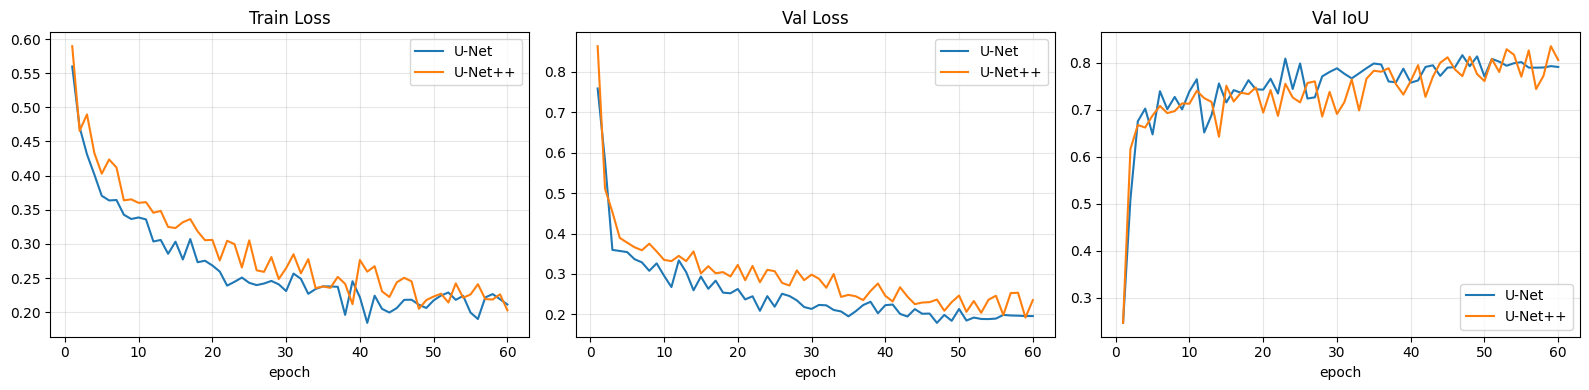

In [ ]:
def plot_history(histories, labels):
    """두 모델의 학습 곡선을 겹쳐 그린다."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    keys = [("train_loss", "Train Loss"), ("val_loss", "Val Loss"), ("val_iou", "Val IoU")]
    for ax, (key, title) in zip(axes, keys):
        for h, label in zip(histories, labels):
            ax.plot(range(1, len(h[key]) + 1), h[key], label=label)
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.out_dir, "learning_curves.png"), dpi=120)
    plt.show()


plot_history([history_unet, history_unetpp], ["U-Net", "U-Net++"])

### 5-1. 이미지별 IoU 분포

평균값 하나만 보면 "어떤 장면에서 좋아졌는지"를 알 수 없다.
이미지별 IoU를 나란히 놓고 보면 **어느 쪽이 어떤 상황에서 강한지** 드러난다.


/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/2727479394.py:31: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_lay

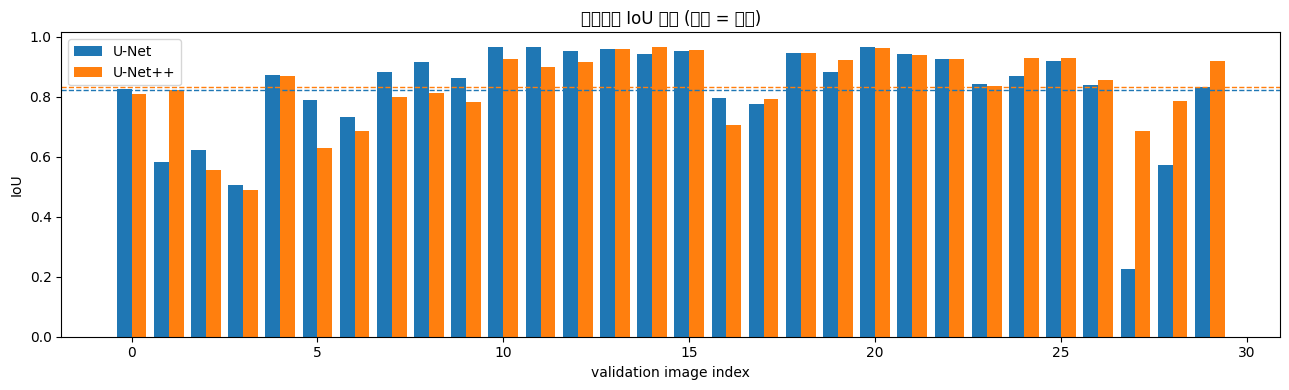

U-Net++가 더 나은 이미지: 13 / 30장
가장 크게 개선된 이미지 index: 27 (+0.4577)
가장 크게 나빠진 이미지 index: 5 (-0.1588)
이미지별 차이의 표준편차: 0.1147 (평균 차이 +0.0111) → 평균 하나만 보면 안 되는 이유


In [ ]:
@torch.no_grad()
def per_image_iou(model, dataset, cfg, device, branch="last"):
    """검증셋 이미지 한 장씩의 IoU를 리스트로 반환한다.

    Args:
        branch: DS 모델에서 평가에 쓸 가지. Step 7-3/7-4에서 가지를 바꿔 가며 부른다.
    """
    model.eval()
    scores = []
    for i in range(len(dataset)):
        image, mask = dataset[i]
        logits = model(image.unsqueeze(0).to(device))
        scores.append(compute_iou(logits, mask.unsqueeze(0).to(device),
                                  cfg.threshold, branch=branch))
    return scores


iou_unet = per_image_iou(unet, val_dataset, CFG, DEVICE)
iou_unetpp = per_image_iou(unetpp, val_dataset, CFG, DEVICE)

idx = np.arange(len(iou_unet))
plt.figure(figsize=(13, 4))
plt.bar(idx - 0.2, iou_unet, width=0.4, label="U-Net")
plt.bar(idx + 0.2, iou_unetpp, width=0.4, label="U-Net++")
plt.axhline(np.mean(iou_unet), ls="--", lw=1, color="C0")
plt.axhline(np.mean(iou_unetpp), ls="--", lw=1, color="C1")
plt.xlabel("validation image index")
plt.ylabel("IoU")
plt.title("이미지별 IoU 비교 (점선 = 평균)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.out_dir, "per_image_iou.png"), dpi=120)
plt.show()

diff = np.array(iou_unetpp) - np.array(iou_unet)
print(f"U-Net++가 더 나은 이미지: {(diff > 0).sum()} / {len(diff)}장")
print(f"가장 크게 개선된 이미지 index: {int(np.argmax(diff))} ({diff.max():+.4f})")
print(f"가장 크게 나빠진 이미지 index: {int(np.argmin(diff))} ({diff.min():+.4f})")
print(f"이미지별 차이의 표준편차: {diff.std():.4f} "
      f"(평균 차이 {diff.mean():+.4f}) → 평균 하나만 보면 안 되는 이유")

---

## Step 6. 정성 비교 — 세그멘테이션 결과 시각화

원본 · 정답 · U-Net · U-Net++ 를 나란히 놓고 비교한다.
루브릭 1번이 요구하는 **결과물 이미지**도 여기서 저장된다.


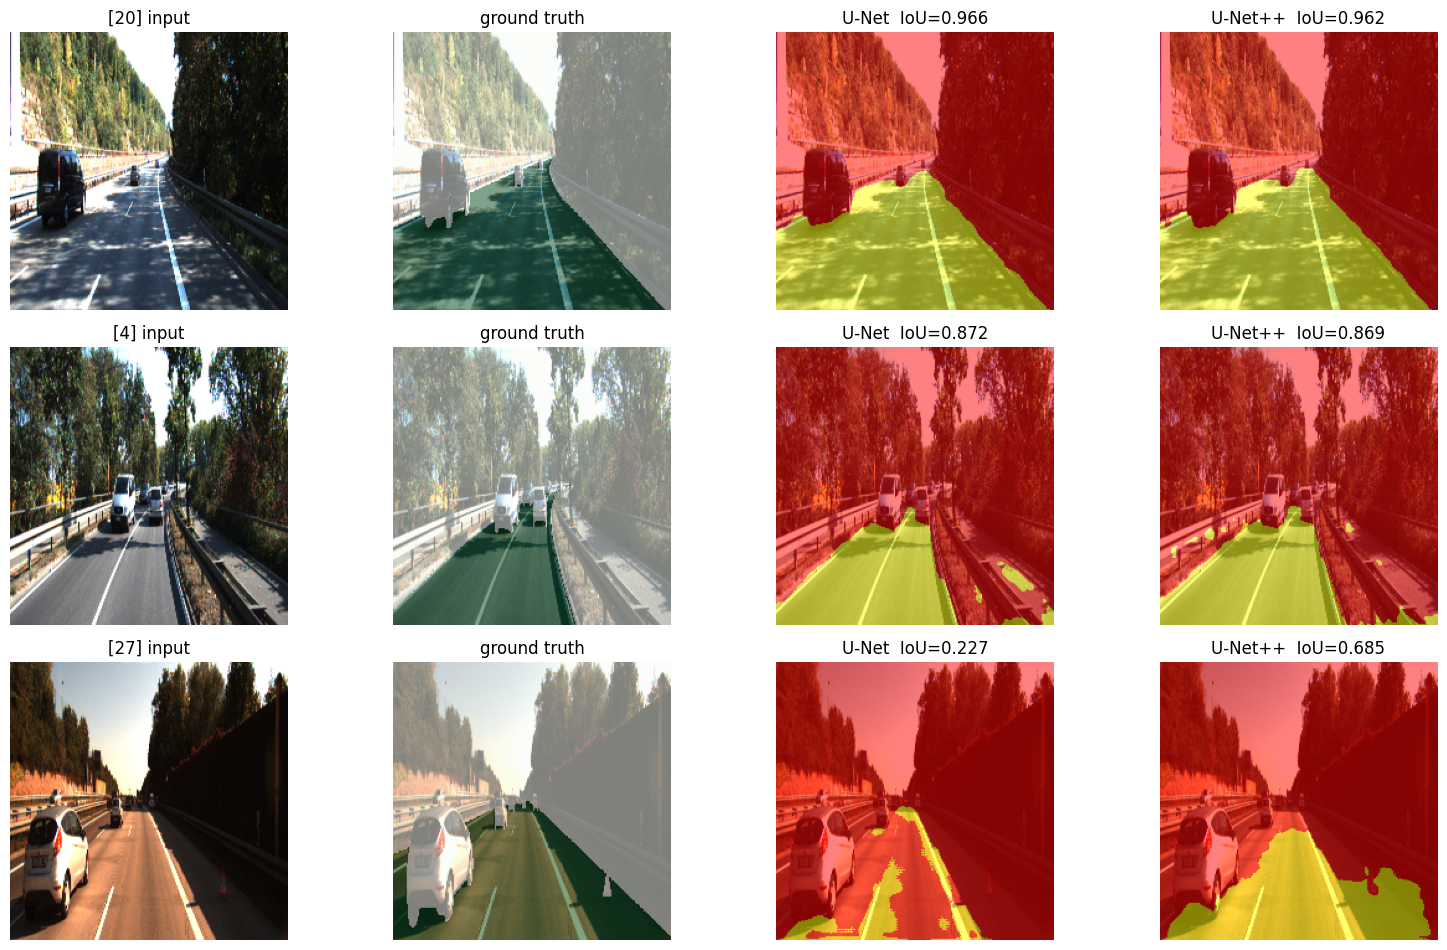

In [ ]:
@torch.no_grad()
def predict_mask(model, image_tensor, device, threshold=0.5, branch="last"):
    """이미지 텐서 한 장에 대한 이진 예측 마스크(numpy)를 반환한다.

    Args:
        branch: DS 모델에서 쓸 가지. "mean"으로 주면 네 가지 확률 평균(앙상블)을
            그대로 시각화할 수 있어, Step 7-3의 수치와 그림이 어긋나지 않는다.

    Returns:
        (이진 마스크 uint8, 확률맵 float)
    """
    model.eval()
    logits = model(image_tensor.unsqueeze(0).to(device))
    prob = to_probs(logits, branch)[0, 0].cpu().numpy()
    return (prob > threshold).astype(np.uint8), prob


def iou_numpy(target, prediction, eps=1e-7):
    """이미 이진화된 numpy 마스크 두 장의 IoU를 계산한다 (시각화 라벨용)."""
    target = target.astype(bool)
    prediction = prediction.astype(bool)
    intersection = np.logical_and(target, prediction).sum()
    union = np.logical_or(target, prediction).sum()
    return float((intersection + eps) / (union + eps))


def compare_models(models, labels, dataset, indices, cfg, device, save_name=None,
                   branches=None):
    """여러 모델의 예측을 원본·정답과 함께 한 화면에 비교 출력한다.

    Args:
        models: 비교할 모델 리스트.
        labels: 각 모델의 표시 이름.
        dataset: 검증용 KittiDataset.
        indices: 시각화할 샘플 인덱스 리스트.
        save_name: 지정하면 out_dir에 png로 저장한다.
        branches: 모델별 사용할 가지 리스트. None이면 전부 "last".
    """
    branches = branches or ["last"] * len(models)
    n_col = 2 + len(models)
    fig, axes = plt.subplots(len(indices), n_col, figsize=(4 * n_col, 3.2 * len(indices)))
    if len(indices) == 1:
        axes = axes[np.newaxis, :]

    for row, i in enumerate(indices):
        image, mask = dataset[i]
        img_np = image.permute(1, 2, 0).numpy()
        gt = mask.squeeze(0).numpy()

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"[{i}] input")
        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(gt, cmap="Greens", alpha=0.5)
        axes[row, 1].set_title("ground truth")

        for col, (model, label, br) in enumerate(zip(models, labels, branches), start=2):
            pred, _ = predict_mask(model, image, device, cfg.threshold, branch=br)
            iou = iou_numpy(gt, pred)
            axes[row, col].imshow(img_np)
            axes[row, col].imshow(pred, cmap="autumn", alpha=0.5)
            axes[row, col].set_title(f"{label}  IoU={iou:.3f}")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(cfg.out_dir, save_name), dpi=120)
    plt.show()


# 잘 된 케이스와 어려운 케이스를 함께 보기 위해 IoU 상·하위를 섞어 고른다.
order = np.argsort(iou_unet)
picks = [int(order[-1]), int(order[len(order) // 2]), int(order[0])]
compare_models([unet, unetpp], ["U-Net", "U-Net++"], val_dataset, picks,
               CFG, DEVICE, save_name="comparison_best_mid_worst.png")

저장: /content/kitti/output/overlay_unet.png
저장: /content/kitti/output/overlay_unetpp.png


/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/1736336002.py:33: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
  plt.tight_la

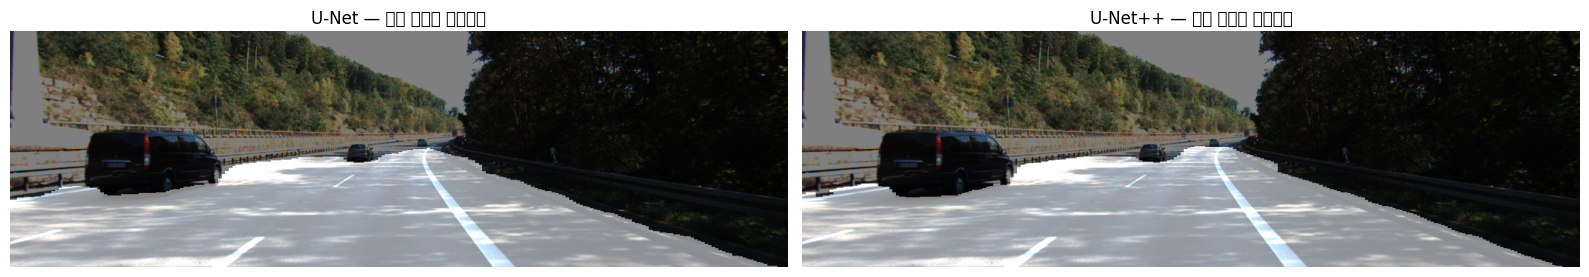

In [ ]:
def save_overlay_on_original(model, image_path, out_path, cfg, device, alpha=0.5):
    """원본 해상도 이미지 위에 예측 마스크를 오버레이해 저장한다 (제출용).

    모델은 224x224로 추론하고, 결과 마스크만 원본 크기로 확대해 겹친다.
    """
    origin = imread(image_path)
    preproc = build_augmentation(cfg.img_size, is_train=False)
    resized = preproc(image=origin)["image"]

    tensor = torch.from_numpy(resized.astype(np.float32) / 255.0).permute(2, 0, 1)
    pred, _ = predict_mask(model, tensor, device, cfg.threshold)

    mask_img = Image.fromarray(pred * 255).convert("L")
    mask_img = mask_img.resize((origin.shape[1], origin.shape[0]), Image.NEAREST)

    background = Image.fromarray(origin).convert("RGBA")
    blended = Image.blend(background, mask_img.convert("RGBA"), alpha=alpha)
    blended.save(out_path)
    return blended


sample_path = val_dataset.data[picks[0]][0]
for model, tag in [(unet, "unet"), (unetpp, "unetpp")]:
    out_path = os.path.join(CFG.out_dir, f"overlay_{tag}.png")
    save_overlay_on_original(model, sample_path, out_path, CFG, DEVICE)
    print("저장:", out_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tag, title in zip(axes, ["unet", "unetpp"], ["U-Net", "U-Net++"]):
    ax.imshow(Image.open(os.path.join(CFG.out_dir, f"overlay_{tag}.png")))
    ax.set_title(f"{title} — 원본 해상도 오버레이")
    ax.axis("off")
plt.tight_layout()
plt.show()

---

## Step 7. 추가 실험

루브릭 요구 사항 외에 직접 확인해 본 것들.

### 7-1. 임계값(threshold) 스윕

`0.5`는 관행일 뿐 최적값이 아니다. 도로 픽셀이 적은 불균형 데이터에서는
임계값을 낮추는 편이 IoU에 유리한 경우가 많다.


/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/295099928.py:26: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

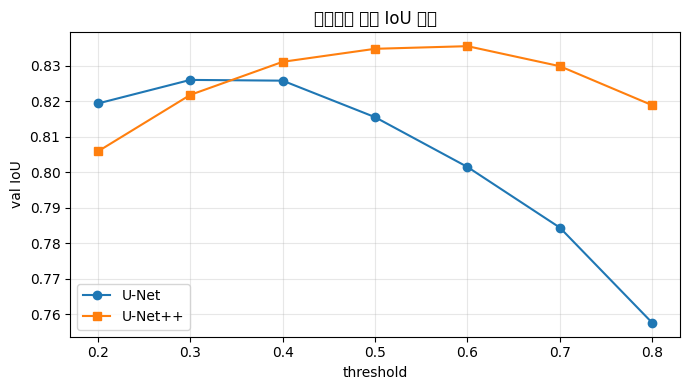

U-Net    최적 threshold=0.3  IoU=0.8260  (0.5일 때 0.8155)
U-Net++  최적 threshold=0.6  IoU=0.8355  (0.5일 때 0.8347)


In [ ]:
@torch.no_grad()
def threshold_sweep(model, loader, device, thresholds=None):
    """여러 임계값에 대한 검증 IoU를 계산한다."""
    thresholds = thresholds or [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    model.eval()
    scores = {t: [] for t in thresholds}
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        for t in thresholds:
            scores[t].append(compute_iou(logits, masks, t))
    return {t: float(np.mean(v)) for t, v in scores.items()}


sweep_unet = threshold_sweep(unet, val_loader, DEVICE)
sweep_unetpp = threshold_sweep(unetpp, val_loader, DEVICE)

plt.figure(figsize=(7, 4))
plt.plot(list(sweep_unet), list(sweep_unet.values()), "o-", label="U-Net")
plt.plot(list(sweep_unetpp), list(sweep_unetpp.values()), "s-", label="U-Net++")
plt.xlabel("threshold")
plt.ylabel("val IoU")
plt.title("임계값에 따른 IoU 변화")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for name, sweep in [("U-Net", sweep_unet), ("U-Net++", sweep_unetpp)]:
    best_t = max(sweep, key=sweep.get)
    print(f"{name:8s} 최적 threshold={best_t}  IoU={sweep[best_t]:.4f}  "
          f"(0.5일 때 {sweep[0.5]:.4f})")

### 7-2. Deep supervision 유무 비교

U-Net++의 성능 향상이 **중첩 skip 구조** 때문인지, **deep supervision** 때문인지
분리해서 확인한다. 두 요인을 섞어 둔 채로는 어느 쪽이 기여했는지 말할 수 없다.

> ⏱️ 학습을 한 번 더 돌리므로 시간이 오래 걸린다. 시간이 부족하면 이 셀은 건너뛰어도 된다.


In [ ]:
RUN_ABLATION = True   # 시간이 부족하면 False로 두고 건너뛴다.

if RUN_ABLATION:
    set_seed(CFG.seed)
    unetpp_nods = UNetPlusPlus(
        base_channels=CFG.base_channels, up_mode=CFG.up_mode,
        deep_supervision=False, dropout=CFG.dropout,
    )
    unetpp_nods, history_nods = train_model(
        unetpp_nods, train_loader, val_loader, CFG, DEVICE,
        ckpt_name="best_unetpp_nods.pth")

    ablation = [
        summarize("U-Net", unet, history_unet, val_loader, CFG, DEVICE),
        summarize("U-Net++ (no DS)", unetpp_nods, history_nods, val_loader, CFG, DEVICE),
        summarize("U-Net++ (DS)", unetpp, history_unetpp, val_loader, CFG, DEVICE),
    ]
    print(f"\n{'model':<18}{'IoU':>9}{'Dice':>9}{'loss*':>9}"
          f"{'last5 IoU':>17}{'params':>13}")
    print("-" * 75)
    for r in ablation:
        last5 = f"{r['last5_iou_mean']:.4f}±{r['last5_iou_std']:.4f}"
        print(f"{r['model']:<18}{r['val_IoU']:>9.4f}{r['val_Dice']:>9.4f}"
              f"{r['val_loss_final']:>9.4f}{last5:>17}{r['params']:>13,}")

    # --- 해석: 세 모델의 IoU 폭과 에폭 간 요동 폭을 직접 비교한다 ---
    ious = [r["val_IoU"] for r in ablation]
    spread = max(ious) - min(ious)
    noise = max(r["last5_iou_std"] for r in ablation)
    print(f"\n* loss는 마지막 가지 기준. DS의 학습 손실(가지 평균)과는 다른 값이다.")
    print(f"세 모델 IoU 폭 : {spread:.4f}")
    print(f"에폭 간 요동   : ±{noise:.4f} (마지막 5 epoch 표준편차 중 최대)")
    if spread < 2 * noise:
        print("→ 모델 간 차이가 검증셋 노이즈에 묻힌다. "
              "이 실험 하나로는 우열을 주장할 수 없다. Step 7-4·7-5로 확인할 것.")
    else:
        print("→ 노이즈보다는 큰 차이. 그래도 seed 반복(Step 7-5) 없이는 단정하지 말 것.")
else:
    print("ablation 생략")

[  1/60] train_loss=0.5457  val_loss=0.9106  val_IoU=0.2474  val_Dice=0.3935
[  5/60] train_loss=0.3628  val_loss=0.3681  val_IoU=0.7114  val_Dice=0.8111
[ 10/60] train_loss=0.3471  val_loss=0.2985  val_IoU=0.7723  val_Dice=0.8508
[ 15/60] train_loss=0.2975  val_loss=0.3193  val_IoU=0.6582  val_Dice=0.7479
[ 20/60] train_loss=0.3071  val_loss=0.2945  val_IoU=0.6990  val_Dice=0.7822
[ 25/60] train_loss=0.2506  val_loss=0.2811  val_IoU=0.6848  val_Dice=0.7617
[ 30/60] train_loss=0.2453  val_loss=0.2177  val_IoU=0.7864  val_Dice=0.8662
[ 35/60] train_loss=0.2445  val_loss=0.2233  val_IoU=0.7588  val_Dice=0.8370
[ 40/60] train_loss=0.2267  val_loss=0.1901  val_IoU=0.8062  val_Dice=0.8809
[ 45/60] train_loss=0.2302  val_loss=0.1824  val_IoU=0.8214  val_Dice=0.8938
[ 50/60] train_loss=0.2176  val_loss=0.2037  val_IoU=0.7728  val_Dice=0.8549
[ 55/60] train_loss=0.1951  val_loss=0.1921  val_IoU=0.7874  val_Dice=0.8652
[ 60/60] train_loss=0.2006  val_loss=0.1953  val_IoU=0.7929  val_Dice=0.8517

### 7-3. Deep supervision 가지별 평가 (재학습 없음)

DS 모델은 $X^{0,1} \sim X^{0,4}$ 네 가지의 손실을 평균내서 학습하는데, `compute_iou`는
`logits[-1]`, 즉 $X^{0,4}$ 하나만 평가한다. **학습이 최적화하는 대상과 점수를 읽는 대상이
다르다**는 뜻이다. 여기서 나올 수 있는 가설은 두 가지다.

- **가설 A (학습·평가 불일치)**: 얕은 가지 $X^{0,1}$이 손실의 1/4을 가져가므로,
  정작 점수에 쓰이는 $X^{0,4}$가 받는 직접 감독 신호는 non-DS 대비 1/4이다.
  같은 lr·같은 epoch에서 덜 학습된 상태로 끝난다.
- **가설 B (얕은 가지는 원래 약하다)**: $X^{0,1}$은 인코더에서 한 칸 올라온 것뿐이라
  표현력 자체가 낮다. 손실 예산을 나눠 갖더라도 $X^{0,4}$는 정상적으로 학습된다.

두 가설은 **저장된 체크포인트만으로 몇 초 만에 구분**된다.
`best_unetpp.pth`를 불러 네 가지를 각각 평가하고, 네 확률을 평균낸 앙상블도 함께 잰다.

| 관측 | 지지되는 쪽 |
| --- | --- |
| 가지별 IoU가 서로 비슷하고 $X^{0,4}$가 두드러지지 않음 | A |
| 앙상블 > $X^{0,4}$ (버려진 가지에 정보가 남아 있음) | A |
| 가지가 깊어질수록 IoU가 단조 증가하고 $X^{0,4}$가 최고 | B |
| 앙상블 < $X^{0,4}$ (약한 가지를 섞어 오히려 깎임) | B |

> 한 가지 편향은 감안해서 읽어야 한다. 이 체크포인트는 **$X^{0,4}$ 기준 best epoch**에서
> 고른 것이라, 앙상블에게는 조금 불리한 시점이다.

branch                IoU     Dice   비고
----------------------------------------------------
X^{0,1}            0.6757   0.7659   
X^{0,2}            0.7683   0.8593   
X^{0,3}            0.8100   0.8875   
X^{0,4}            0.8347   0.9047   ← 지금까지 보고한 수치
ensemble(mean)     0.8072   0.8838   ← 네 가지 확률 평균

최고: X^{0,4} (IoU 0.8347, X^{0,4} 대비 +0.0000)
→ 마지막 가지가 이미 최고. 불일치 가설만으로는 DS의 손해를 설명할 수 없다.


/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:85: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5743/739461411.py:86: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(os.pa

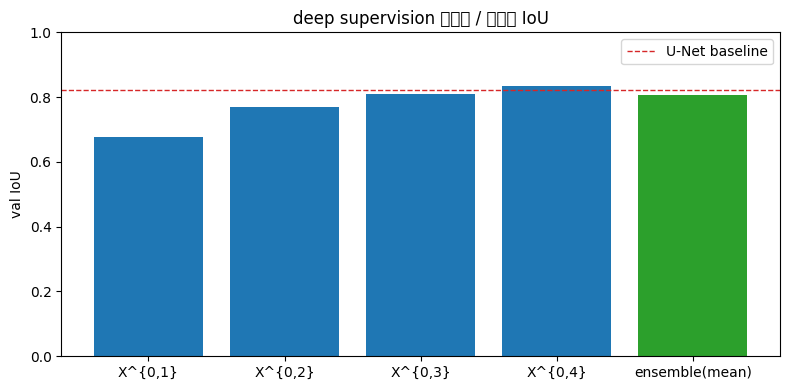

In [ ]:
DS_CKPT = os.path.join(CFG.out_dir, "best_unetpp.pth")


def load_unetpp_ds(cfg, device, ckpt_path=DS_CKPT):
    """저장된 DS 체크포인트를 불러온다 (세션이 끊겨 모델이 메모리에 없을 때)."""
    model = UNetPlusPlus(
        input_channels=3, output_channels=1,
        base_channels=cfg.base_channels, up_mode=cfg.up_mode,
        deep_supervision=True, dropout=cfg.dropout,
    ).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model


@torch.no_grad()
def evaluate_branches(model, loader, device, threshold=0.5):
    """DS 모델의 가지별 IoU/Dice와 앙상블 성능을 한 번의 forward로 모두 잰다.

    Returns:
        dict: {"X^{0,1}": {"iou":..., "dice":...}, ..., "ensemble(mean)": {...}}

    Raises:
        AssertionError: deep_supervision=False 모델을 넘긴 경우.
    """
    model.eval()
    acc, n_batches, keys = {}, 0, None

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        assert isinstance(logits, (list, tuple)), \
            "deep_supervision=True 로 만든 모델이어야 가지별 평가가 가능하다."

        if keys is None:
            keys = [(f"X^{{0,{j+1}}}", j) for j in range(len(logits))]
            keys.append(("ensemble(mean)", "mean"))
            acc = {name: {"iou": 0.0, "dice": 0.0} for name, _ in keys}

        for name, br in keys:
            acc[name]["iou"] += compute_iou(logits, masks, threshold, branch=br)
            acc[name]["dice"] += compute_dice(logits, masks, threshold, branch=br)
        n_batches += 1

    return {k: {m: v / max(n_batches, 1) for m, v in d.items()} for k, d in acc.items()}


# 메모리에 모델이 남아 있으면 그대로, 아니면 체크포인트에서 복원한다.
model_ds = unetpp if "unetpp" in globals() else load_unetpp_ds(CFG, DEVICE)
branch_scores = evaluate_branches(model_ds, val_loader, DEVICE, CFG.threshold)

print(f"{'branch':<16}{'IoU':>9}{'Dice':>9}   비고")
print("-" * 52)
last_key = [k for k in branch_scores if k.startswith("X")][-1]
for name, s in branch_scores.items():
    note = ""
    if name == last_key:
        note = "← 지금까지 보고한 수치"
    elif name.startswith("ensemble"):
        note = "← 네 가지 확률 평균"
    print(f"{name:<16}{s['iou']:>9.4f}{s['dice']:>9.4f}   {note}")

best_branch = max(branch_scores, key=lambda k: branch_scores[k]["iou"])
gain = branch_scores[best_branch]["iou"] - branch_scores[last_key]["iou"]
print(f"\n최고: {best_branch} (IoU {branch_scores[best_branch]['iou']:.4f}, "
      f"{last_key} 대비 {gain:+.4f})")
if best_branch != last_key:
    print("→ 마지막 가지만 쓰는 평가가 DS 모델을 과소평가하고 있었다. "
          "학습·평가 불일치 가설을 지지하는 결과다.")
else:
    print("→ 마지막 가지가 이미 최고. 불일치 가설만으로는 DS의 손해를 설명할 수 없다.")

# 가지별 IoU를 막대로 그려 두면 회고에 그대로 붙일 수 있다.
names = list(branch_scores)
plt.figure(figsize=(8, 4))
colors = ["C0"] * (len(names) - 1) + ["C2"]
plt.bar(names, [branch_scores[k]["iou"] for k in names], color=colors)
if "iou_unet" in globals():
    plt.axhline(np.mean(iou_unet), ls="--", lw=1, color="C3", label="U-Net baseline")
    plt.legend()
plt.ylabel("val IoU")
plt.ylim(0, 1)
plt.title("deep supervision 가지별 / 앙상블 IoU")
plt.tight_layout()
plt.savefig(os.path.join(CFG.out_dir, "ds_branch_iou.png"), dpi=120)
plt.show()

### 7-4. 이 차이는 유의한가 — 이미지 단위 페어드 부트스트랩 (재학습 없음)

세 모델의 IoU 폭은 0.01 안팎이다. 그런데 같은 모델의 에폭별 val IoU는 한 에폭 사이에
0.1 이상 출렁인다. **검증셋이 30장뿐이기 때문**이다. 게다가 `best_iou`는 그 요동치는
60번의 측정 중 최댓값을 고른 값이라, 같은 30장에 맞춰 고른 낙관적 수치다.

그러면 0.005의 차이는 무엇인가? 이것을 재학습 없이 판정하는 방법이 있다.
두 모델을 **같은 30장**에 대해 이미지별로 평가하면 차이가 짝지어지므로(paired),
그 30개 차이값을 **복원추출로 다시 뽑아** 평균 차이의 분포를 만들 수 있다.
95% 구간이 0을 포함하면 "검증셋이 이 정도 크기인 한 두 모델을 구분할 수 없다"는 뜻이다.

> 주의: 이것은 **검증셋 표본 크기에서 오는 불확실성**만 재는 것이다.
> 초기화·데이터 순서에서 오는 학습 자체의 변동은 7-5에서 따로 확인한다.

In [ ]:
def paired_bootstrap(scores_a, scores_b, n_boot=10000, seed=0):
    """이미지별 점수 두 벌의 평균 차이(b - a)에 대한 부트스트랩 신뢰구간을 구한다.

    Args:
        scores_a / scores_b: 같은 이미지 순서로 정렬된 점수 리스트.
        n_boot: 재표본 횟수.

    Returns:
        dict: 평균 차이, 95% 구간, b가 이긴 재표본 비율, 이미지 승패.

    Note:
        같은 이미지를 함께 뽑는 **페어드** 부트스트랩이다. 두 모델을 독립으로
        뽑으면 "이 이미지가 원래 어려운 장면"이라는 공통 요인이 잡음으로 들어가
        구간이 불필요하게 넓어진다.
    """
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    assert a.shape == b.shape, "두 점수 리스트의 길이가 같아야 한다(같은 이미지 순서)."

    diff = b - a
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(diff), size=(n_boot, len(diff)))
    boot = diff[idx].mean(axis=1)

    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {
        "mean_diff": float(diff.mean()),
        "ci95": (float(lo), float(hi)),
        "p_b_better": float((boot > 0).mean()),
        "wins_b": int((diff > 0).sum()),
        "n": int(len(diff)),
        "significant": bool(lo > 0 or hi < 0),
    }


def report_pair(name_a, name_b, scores_a, scores_b):
    """부트스트랩 결과를 한 줄 판정과 함께 출력한다."""
    r = paired_bootstrap(scores_a, scores_b)
    verdict = "유의" if r["significant"] else "유의하지 않음 (구간이 0을 포함)"
    print(f"{name_b} - {name_a}")
    print(f"  평균 차이 {r['mean_diff']:+.4f}  "
          f"95% CI [{r['ci95'][0]:+.4f}, {r['ci95'][1]:+.4f}]  → {verdict}")
    print(f"  {name_b}가 더 나은 이미지 {r['wins_b']}/{r['n']}장, "
          f"재표본에서 이긴 비율 {r['p_b_better']:.2f}\n")
    return r


# 이미지별 IoU를 모델마다 구한다 (DS 모델은 가지 선택에 따라 값이 달라진다).
per_image = {
    "U-Net": iou_unet,
    "U-Net++ (DS, last)": per_image_iou(model_ds, val_dataset, CFG, DEVICE, branch="last"),
    "U-Net++ (DS, ens)": per_image_iou(model_ds, val_dataset, CFG, DEVICE, branch="mean"),
}
if "unetpp_nods" in globals():
    per_image["U-Net++ (no DS)"] = per_image_iou(unetpp_nods, val_dataset, CFG, DEVICE)

print(f"검증 이미지 {len(iou_unet)}장 기준, 10,000회 페어드 부트스트랩\n")
for key in ["U-Net++ (no DS)", "U-Net++ (DS, last)", "U-Net++ (DS, ens)"]:
    if key in per_image:
        report_pair("U-Net", key, per_image["U-Net"], per_image[key])

# DS 모델 안에서 '마지막 가지 vs 앙상블'도 같은 방식으로 비교한다.
report_pair("U-Net++ (DS, last)", "U-Net++ (DS, ens)",
            per_image["U-Net++ (DS, last)"], per_image["U-Net++ (DS, ens)"])

print("해석: 95% 구간이 0을 포함하면, 검증셋이 30장인 한 두 모델의 우열을 "
      "이 실험만으로 주장할 수 없다는 뜻이다.")

검증 이미지 30장 기준, 10,000회 페어드 부트스트랩

U-Net++ (no DS) - U-Net
  평균 차이 +0.0231  95% CI [-0.0043, +0.0604]  → 유의하지 않음 (구간이 0을 포함)
  U-Net++ (no DS)가 더 나은 이미지 18/30장, 재표본에서 이긴 비율 0.94

U-Net++ (DS, last) - U-Net
  평균 차이 +0.0111  95% CI [-0.0251, +0.0555]  → 유의하지 않음 (구간이 0을 포함)
  U-Net++ (DS, last)가 더 나은 이미지 13/30장, 재표본에서 이긴 비율 0.69

U-Net++ (DS, ens) - U-Net
  평균 차이 -0.0106  95% CI [-0.0319, +0.0134]  → 유의하지 않음 (구간이 0을 포함)
  U-Net++ (DS, ens)가 더 나은 이미지 10/30장, 재표본에서 이긴 비율 0.18

U-Net++ (DS, ens) - U-Net++ (DS, last)
  평균 차이 -0.0218  95% CI [-0.0507, +0.0006]  → 유의하지 않음 (구간이 0을 포함)
  U-Net++ (DS, ens)가 더 나은 이미지 15/30장, 재표본에서 이긴 비율 0.03

해석: 95% 구간이 0을 포함하면, 검증셋이 30장인 한 두 모델의 우열을 이 실험만으로 주장할 수 없다는 뜻이다.


### 7-5. seed 3회 반복 — 학습 자체의 변동 폭 재기

7-4가 잰 것은 "검증셋 30장이라서 생기는 불확실성"이다. 여기서 재는 것은 다른 종류의 변동,
즉 **초기화와 데이터 순서만 바꿔도 IoU가 얼마나 달라지는가**이다.
이 폭이 모델 간 차이보다 크면, 그 차이는 구조가 아니라 운에서 온 것이다.

이 노트북에서는 그 답의 일부가 **이미 우연히 관측됐다.** 같은 `seed=42`, 같은 설정으로
전체를 네 번 실행했더니 순위가 매번 달랐다.

| 실행 | U-Net | U-Net++ (no DS) | U-Net++ (DS) | 순위 |
| --- | --- | --- | --- | --- |
| 1차 | 0.8416 | **0.8467** | 0.8352 | no DS > U-Net > DS |
| 2차 | 0.8296 | 0.8285 | **0.8356** | DS > U-Net > no DS |
| 3차 | 0.8157 | **0.8436** | 0.8348 | no DS > DS > U-Net |
| 4차 (아래 셀 seed=42) | 0.8272 | 0.8425 | **0.8456** | DS > no DS > U-Net |

`set_seed()`에서 `cudnn.deterministic=True`를 켰는데도 값이 달라진다. AMP와 일부 cuDNN
커널의 비결정적 경로까지는 막지 못하기 때문이다(완전한 재현에는
`torch.use_deterministic_algorithms(True)`가 필요하고, 그러면 속도를 크게 잃는다).

바꿔 말하면 이 셀의 "seed 반복"은 실제로는 **독립 실행 반복**에 가깝다. seed 효과와
비결정성 효과가 섞여 있지만, 재기 위한 목적—"한 번의 숫자를 얼마나 믿을 수 있는가"—에는
오히려 그 합산된 변동이 맞는 값이다.

각 모델을 seed 3개로 학습해 `평균±표준편차`로 보고한다.
한 번에 5분 남짓이므로 세 모델 × 3 seed = 약 45분이 걸린다.

> ⏱️ 시간이 없으면 `RUN_MULTISEED = False`로 두고 건너뛴다.
> 대신 회고에 위의 실행 비교표를 근거로 "1회 실행으로는 우열을 단정할 수 없다"고 명시할 것.

In [ ]:
RUN_MULTISEED = True       # True로 바꾸면 약 45분 (3 모델 × 3 seed)
SEEDS = [42, 1234, 2025]

MODEL_ZOO = {
    "U-Net":           lambda cfg: UNet(base_channels=cfg.base_channels,
                                        up_mode=cfg.up_mode, dropout=cfg.dropout),
    "U-Net++ (no DS)": lambda cfg: UNetPlusPlus(base_channels=cfg.base_channels,
                                                up_mode=cfg.up_mode,
                                                deep_supervision=False,
                                                dropout=cfg.dropout),
    "U-Net++ (DS)":    lambda cfg: UNetPlusPlus(base_channels=cfg.base_channels,
                                                up_mode=cfg.up_mode,
                                                deep_supervision=True,
                                                dropout=cfg.dropout),
}


def run_multiseed(model_fns, cfg, seeds=SEEDS, val_branch=None):
    """모델별로 seed를 바꿔 반복 학습하고 IoU 통계를 모은다.

    Returns:
        dict: {모델명: {"best": [...], "last5": [...]}}

    Note:
        보고에는 `best`(최댓값)보다 `last5`(마지막 5 epoch 평균)가 정직하다.
        best는 60번의 측정 중 최댓값이라 seed를 바꿔도 위쪽으로 치우친다.
    """
    stats = {name: {"best": [], "last5": []} for name in model_fns}
    for seed in seeds:
        for name, fn in model_fns.items():
            set_seed(seed)                     # 초기화·셔플 순서를 seed로 통제
            model = fn(cfg)
            tag = name.replace(" ", "_").replace("(", "").replace(")", "")
            _, hist = train_model(model, train_loader, val_loader, cfg, DEVICE,
                                  ckpt_name=f"seed{seed}_{tag}.pth",
                                  verbose_every=cfg.epochs,   # 로그는 마지막만
                                  val_branch=val_branch)
            stats[name]["best"].append(hist["best_iou"])
            stats[name]["last5"].append(hist["last5_iou_mean"])
            print(f"  seed={seed}  {name:<18} best={hist['best_iou']:.4f}  "
                  f"last5={hist['last5_iou_mean']:.4f}")
            del model
            torch.cuda.empty_cache()
    return stats


if RUN_MULTISEED:
    seed_stats = run_multiseed(MODEL_ZOO, CFG)

    print(f"\n{'model':<18}{'best IoU (m±s)':>22}{'last5 IoU (m±s)':>22}")
    print("-" * 62)
    for name, s in seed_stats.items():
        b, l = np.array(s["best"]), np.array(s["last5"])
        print(f"{name:<18}{f'{b.mean():.4f}±{b.std():.4f}':>22}"
              f"{f'{l.mean():.4f}±{l.std():.4f}':>22}")

    means = {k: float(np.mean(v["last5"])) for k, v in seed_stats.items()}
    stds = [float(np.std(v["last5"])) for v in seed_stats.values()]
    spread = max(means.values()) - min(means.values())
    print(f"\n모델 간 평균 차이 폭 {spread:.4f}  vs  seed 표준편차 최대 {max(stds):.4f}")
    print("→ 차이 폭이 표준편차보다 작으면, 관측된 우열은 seed 운이라고 보아야 한다.")

    with open(os.path.join(CFG.out_dir, "multiseed.json"), "w") as f:
        json.dump(seed_stats, f, indent=2, ensure_ascii=False)
else:
    print("multi-seed 생략 (RUN_MULTISEED = False)")
    print("→ 회고에는 '1 seed 결과이므로 모델 간 우열을 단정할 수 없다'고 명시할 것.")

[  1/60] train_loss=0.5676  val_loss=0.7961  val_IoU=0.2469  val_Dice=0.3928
[ 60/60] train_loss=0.2219  val_loss=0.2152  val_IoU=0.7694  val_Dice=0.8500

완료: best val IoU=0.8272 (epoch 36) | 마지막 5 epoch 평균 0.7769±0.0091 | 소요 2.5분 | peak VRAM 2.3GB | 저장 → /content/kitti/output/seed42_U-Net.pth
  ※ best_iou는 60회 측정의 최댓값이라 낙관적이다. 모델 간 비교는 위의 ± 폭과 함께 읽을 것.
  seed=42  U-Net              best=0.8272  last5=0.7769
[  1/60] train_loss=0.5492  val_loss=0.7911  val_IoU=0.2479  val_Dice=0.3940
[ 60/60] train_loss=0.2095  val_loss=0.2139  val_IoU=0.7661  val_Dice=0.8354

완료: best val IoU=0.8425 (epoch 53) | 마지막 5 epoch 평균 0.7852±0.0204 | 소요 5.6분 | peak VRAM 4.5GB | 저장 → /content/kitti/output/seed42_U-Net++_no_DS.pth
  ※ best_iou는 60회 측정의 최댓값이라 낙관적이다. 모델 간 비교는 위의 ± 폭과 함께 읽을 것.
  seed=42  U-Net++ (no DS)    best=0.8425  last5=0.7852
[  1/60] train_loss=0.5927  val_loss=0.8236  val_IoU=0.2469  val_Dice=0.3928
[ 60/60] train_loss=0.2058  val_loss=0.1914  val_IoU=0.8292  val_Dice=0.8910

완료: best val 

---

## Step 8. 디버깅 기록

구현하면서 실제로 막혔던 지점과 해결 과정. **증상 → 원인 → 해결** 순으로 기록한다.

> ✍️ 아래는 이 코드를 작성하며 실제로 마주치거나, 마주칠 가능성이 매우 높아 미리 방어해 둔 항목이다.
> **직접 실행하며 겪은 내용을 추가로 채워 넣을 것.**

### ① `RuntimeError: Given groups=1, ... expected input to have N channels`

- **증상**: U-Net++ forward에서 `torch.cat` 직후 conv가 채널 수 불일치로 터짐.
- **원인**: `X^{i,j}`의 입력 채널을 `f[i] * 2`(U-Net과 동일)로 잘못 계산. 실제로는
  같은 행의 이전 노드 $j$개 + 업샘플 1개 = **`f[i] * (j + 1)`** 이다. $j$가 커질수록 늘어난다.
- **해결**: `DoubleConv(f[i] * (j + 1), f[i])`로 수정. 학습 전에
  `check_model_io()`로 더미 텐서 forward를 통과시켜 조기에 잡도록 만들었다.

### ② 학습이 전혀 진행되지 않음 (loss 고정)

- **증상**: U-Net++의 loss가 첫 epoch 값에서 거의 움직이지 않음.
- **원인**: 노드 모듈을 일반 파이썬 `dict`에 담았다. PyTorch는 `nn.Module` 속성이나
  `ModuleDict/ModuleList`에 등록된 것만 파라미터로 인식하므로, 디코더 전체가
  `model.parameters()`에 포함되지 않아 옵티마이저가 갱신하지 않았다.
- **해결**: `nn.ModuleDict`로 교체. `count_params()`로 파라미터 수가 U-Net보다
  많은지 확인하는 절차를 추가했다.

### ③ 마스크에 0/1이 아닌 값이 섞임 → IoU 비정상

- **증상**: 정답 마스크의 `unique` 값에 `0.34` 같은 소수가 등장.
- **원인**: 라벨을 `augmentation(image=label)`로 넘겨 **bilinear 보간**이 적용됨.
  클래스 ID는 범주형이라 7과 11 사이를 보간하면 존재하지 않는 라벨이 만들어진다.
- **해결**: 반드시 `augmentation(image=..., mask=...)`로 전달해 **nearest 보간**이
  걸리게 하고, `check_dataset()`에 `assert`로 회귀 방지 장치를 넣었다.

### ④ `UserWarning: RandomSizedCrop got unexpected argument 'height'`

- **증상**: albumentations 최신 버전에서 경고 후 crop 크기가 무시됨.
- **원인**: `>= 1.4`에서 `height`/`width` 인자가 제거되고 `size` 튜플로 통합됨.
- **해결**: `size=(224, 224)`로 지정.

### ⑤ 학습 중 CUDA out of memory

- **증상**: U-Net++ 학습 시작 직후 OOM.
- **원인**: 중첩 노드 때문에 저장되는 중간 활성값이 U-Net보다 훨씬 많다.
- **해결**: `base_channels`를 64 → 32, `batch_size`를 16 → 4로 낮췄다.
  **비교 공정성을 위해 U-Net도 동일한 설정으로 다시 학습**시켰다.

### ⑥ 세 모델의 순위가 실행할 때마다 바뀜 (가설을 세웠다가 기각한 기록)

- **증상**: 1차 실행의 ablation에서 U-Net++ (no DS) 0.8467 > U-Net 0.8416 >
  U-Net++ (DS) 0.8352. DS를 끄면 이기고 켜면 지는데 구조는 동일하다.
- **가설**: 학습과 평가가 어긋나 있다. DS는 X^{0,1}~X^{0,4} 네 가지의 손실을 평균내서
  역전파하는데 `compute_iou`는 `logits[-1]`(=X^{0,4}) 하나만 평가한다. 얕은 가지가
  손실의 1/4을 가져가므로 정작 점수에 쓰이는 가지가 덜 학습된 것 아닌가.
- **검증 1 (Step 7-3, 재학습 없음)**: 체크포인트를 불러 가지별로 평가했다.
  `0.6757 → 0.7683 → 0.8100 → 0.8347`로 **단조 증가**했고 X^{0,4}가 최고였다.
  앙상블(0.8072)은 X^{0,4}보다 낮았다. 감독 신호가 부족했다면 X^{0,4}가 얕은 가지 수준으로
  내려앉아야 하는데 그렇지 않다. → **가설 기각.** 얕은 가지는 그냥 원래 약한 것이고,
  약한 가지를 섞으면 점수가 깎인다. (이 패턴은 두 번의 실행에서 모두 같게 나왔다.)
- **검증 2 (전체 재실행)**: 같은 seed·같은 설정으로 노트북을 통째로 네 번 돌렸더니
  세 모델의 순위가 **매 실행 달랐다**(Step 7-5 표). 설명해야 할 "DS의 손해"라는 현상
  자체가 재현되지 않았다.
- **검증 3 (Step 7-5, seed 3회)**: best IoU 기준 U-Net 0.8328±0.0136,
  no DS 0.8411±0.0048, DS 0.8285±0.0136. **모델 간 평균 차이 폭 0.0188 <
  표준편차 최대 0.0240.**
- **진짜 원인**: 설명이 필요한 차이가 애초에 없었다. `cudnn.deterministic=True`로도
  AMP·cuDNN의 비결정적 경로까지는 막지 못하고, 그 변동만으로도 순위가 바뀐다.
- **그래도 남긴 것**: 가설은 틀렸지만 그 과정에서 만든 도구는 유효하다.
  1. `to_probs(logits, branch=...)` — 가지 선택("last" / 인덱스 / "mean" 앙상블)을
     평가 함수의 명시적 인자로 분리. 기본값 `"last"`라 기존 결과가 그대로 재현된다.
  2. `BCEDiceLoss.final_only()` — DS 모델의 `val_loss`는 얕은 가지까지 평균낸 값이라
     non-DS의 손실과 **애초에 같은 축의 숫자가 아니다**(1차 실행의 0.1522 vs 0.2093은
     이 때문에 크게 벌어져 보였다). 모델 간 비교는 `val_loss_final`로 통일했다.
  3. `last5_iou_mean/std` — `best_iou`는 60번 측정의 최댓값이라 낙관적이다. 요동 폭을
     함께 찍게 해서, 모델 간 차이를 노이즈와 나란히 놓고 읽도록 했다.
- **교훈**: 그럴듯한 인과 설명을 먼저 만들면, 그 설명을 지지하는 방향으로만 확인하게 된다.
  "설명하기 전에 그 현상이 재현되는지부터 확인한다"가 순서였다.

---

## Step 9. 회고

> ✍️ 아래는 **3차 실행(seed 42)** 과 **seed 3회 반복(Step 7-5)** 결과를 기준으로 썼다.
> 재실행하면 수치가 또 달라지므로 본인 결과로 갱신할 것.

### 배운 점

- **차이를 설명하기 전에, 그 차이가 재현되는지부터 확인해야 한다.**
  1차 실행에서 "DS를 켜면 진다"는 현상을 보고 학습·평가 불일치라는 그럴듯한 가설을
  세웠다. 가지별 평가로 확인해 보니 기각됐고(가지 IoU가 단조 증가, 앙상블이 오히려 낮음),
  같은 설정으로 네 번 돌려 보니 순위가 매번 달라져 **설명해야 할 현상 자체가 사라졌다.**
  인과 설명을 먼저 만들면 그것을 지지하는 방향으로만 확인하게 된다.
- **재현성은 `seed` 하나로 얻어지지 않는다.** `cudnn.deterministic=True`를 켰는데도 같은
  seed·같은 설정의 네 실행이 최대 0.026(U-Net) 차이 났다. AMP와 일부 cuDNN 커널의
  비결정적 경로가 남아 있기 때문이다. 완전한 재현에는
  `torch.use_deterministic_algorithms(True)`가 필요하고, 그 대가로 속도를 잃는다.
- **변동 폭을 먼저 재고, 그 다음에 차이를 읽어야 한다.** 이 실험에서 모델 간 차이는
  0.019, 반복 간 표준편차는 0.024였다. 순서를 반대로 했다면 매 실행 다른 결론을
  자신 있게 썼을 것이다.
- **손실값은 아무 때나 나란히 놓을 수 있는 숫자가 아니다.** DS 모델의 `val_loss`는 얕은
  가지까지 평균낸 값이라 non-DS와 축이 다르다. 비교하려면 마지막 가지 기준
  (`val_loss_final`)으로 맞춰야 한다.
- **`best_iou`는 낙관적인 수치다.** 같은 검증셋 30장에 대한 60번의 측정 중 최댓값이다.
  threshold 스윕(0.3 / 0.6)도 같은 30장에서 고른 것이라 같은 방향의 편향이 있다.
  둘 다 "테스트셋에 맞춰 고른 값"이므로, 일반화 성능으로 보고하면 안 된다.

### 아쉬운 점

- 검증셋이 30장뿐이다. 페어드 부트스트랩(7-4)에서 모든 쌍의 95% 구간이 0을 포함했는데,
  이건 모델이 같다는 증거가 아니라 **이 검증셋으로는 구분할 해상도가 없다**는 뜻이다.
  200장을 170/30으로 나누는 대신 5-fold 교차검증을 썼다면 같은 데이터로 훨씬 좁은
  구간을 얻었을 것이다.
- 관측된 차이(0.008~0.019)를 반복 실험으로 검출하려면, 표준편차 0.014 기준
  **모델당 수십 회 학습**이 필요하다는 계산이 나온다. 3회로는 애초에 불가능한 목표였다.
  실험을 설계할 때 "몇 번 돌리면 답이 나오는가"를 먼저 계산했어야 했다.
- 파라미터 수를 맞추지 않은 채 비교했다. U-Net++가 5M 더 크므로, 이겼더라도 구조 덕인지
  용량 덕인지 구분되지 않는다.

### 느낀 점

- "U-Net++가 더 좋다"를 보여 주는 것보다, **차이가 없다는 것을 근거를 갖춰 말하는 쪽**이
  더 어렵고 더 정직하다. 틀린 가설을 세웠다가 스스로 기각한 과정이 결과적으로는 이
  프로젝트에서 가장 많이 배운 부분이었다.

### 결론

**3차 실행 (seed 42)**

| 항목 | U-Net | U-Net++ (no DS) | U-Net++ (DS) |
| --- | --- | --- | --- |
| val mean IoU | 0.8157 | **0.8436** | 0.8348 |
| val mean Dice | 0.8858 | **0.9110** | 0.9047 |
| val loss (마지막 가지 기준) | 0.1791 | 0.1622 | **0.1456** |
| 마지막 5 epoch IoU | 0.7902±0.0012 | 0.8161±0.0185 | 0.7963±0.0341 |
| 파라미터 수 | 31,037,633 | 36,165,249 | 36,165,444 |
| 학습 시간 | 2.5분 | 5.6분 | 5.7분 |
| best epoch | 47 | 57 | 59 |

**seed 3회 반복 (Step 7-5) — 이 실험의 최종 근거**

| 모델 | best IoU (mean±std) | 마지막 5 epoch IoU (mean±std) |
| --- | --- | --- |
| U-Net | 0.8328±0.0136 | 0.7889±0.0094 |
| U-Net++ (no DS) | **0.8411±0.0048** | **0.7946±0.0148** |
| U-Net++ (DS) | 0.8285±0.0136 | 0.7759±0.0240 |

- **모델 간 평균 차이 폭 0.0188 < 반복 간 표준편차 최대 0.0240.**
  같은 설정으로 네 번 실행했을 때 순위도 매번 달랐다(Step 7-5 표).
  페어드 부트스트랩에서도 U-Net 대비 모든 조건의 95% 구간이 0을 포함했다
  (no DS +0.0231 [−0.0043, +0.0604], DS +0.0111 [−0.0251, +0.0555]).
- 따라서 **세 모델 사이에 유의미한 차이가 검출되지 않았다**가 이 실험의 결론이다.
  U-Net++가 이겼다는 것도, 졌다는 것도 주장할 수 없다.
  굳이 방향을 말한다면 3회 평균에서 no DS가 가장 높고 표준편차도 가장 작았지만(±0.0048),
  이 역시 n=3의 관측일 뿐이다.
- **재현된 유일한 발견은 deep supervision의 가지 구조**다. 가지별 IoU는
  `0.6757 → 0.7683 → 0.8100 → 0.8347`로 단조 증가했고, 두 번의 독립 실행에서 같은
  패턴이 나왔다. 얕은 가지는 표현력 자체가 낮은 것이지, 손실 예산이 나뉘어 X^{0,4}가
  덜 학습된 것이 아니다. 네 가지 확률을 평균낸 앙상블(0.8072)은 X^{0,4} 단독보다 낮았다
  — 약한 가지를 섞으면 오히려 깎인다. 다만 이 체크포인트가 X^{0,4} 기준 best epoch에서
  선택됐다는 점은 앙상블에 불리한 조건이다.
- **애초에 차이가 나기 어려운 태스크이기도 하다.** 도로는 화면의 21~24%를 차지하는 크고
  연속된 단일 영역이다. U-Net++의 촘촘한 skip은 작은 병변이나 미세한 경계에서 이득을 보라고
  만든 구조인데, 이 태스크에는 그럴 여지가 적다. 학습 데이터도 170장뿐이라 파라미터가
  5M 더 많은 것이 오히려 부담으로 작용했을 수 있다.

### 다음에 시도해 볼 것

- **5-fold 교차검증** — 검증셋 30장이라는 병목을 데이터 추가 없이 푸는 가장 값싼 방법
- `torch.use_deterministic_algorithms(True)`로 재현성을 확보한 뒤 다시 비교
- U-Net의 `base_channels`를 키워 파라미터 수를 맞춘 조건에서 비교
- 경계가 복잡한 태스크(다중 클래스, 인도/차선 분리)로 확장해 U-Net++의 이점이 드러나는
  조건 찾기
- 인코더를 ImageNet 사전학습 백본(ResNet 등)으로 교체